<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I2wUTT12p5bX3RCku_T_82aD4tkY9LVY" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


<b>Комментарий к ноутбуку</b>

Я удалила все блоки, которые не показывают мою работу или мешают восприятию, чтобы сделать документ более читаемым и не таким объёмнымю В частности я удалила импорты библиотек, формулировки заданий, сохранение обученнных моделей в файл и т.п. То есть в текущем виде перезапустить полностью ноутбук не получилось бы, но на всякий случай прикладываю ссылку на более или менее полный запускаемый ноутбук (спасибо колабу за лимиты, а гуглу за три почты, с которых я обучала модели). И да, дальнейшие комментарии будут на английском.

https://drive.google.com/file/d/1T8jw0E9_1zQxkcvKANwIPdLKZOsG9DWg/view?usp=sharing




### Our Dataset

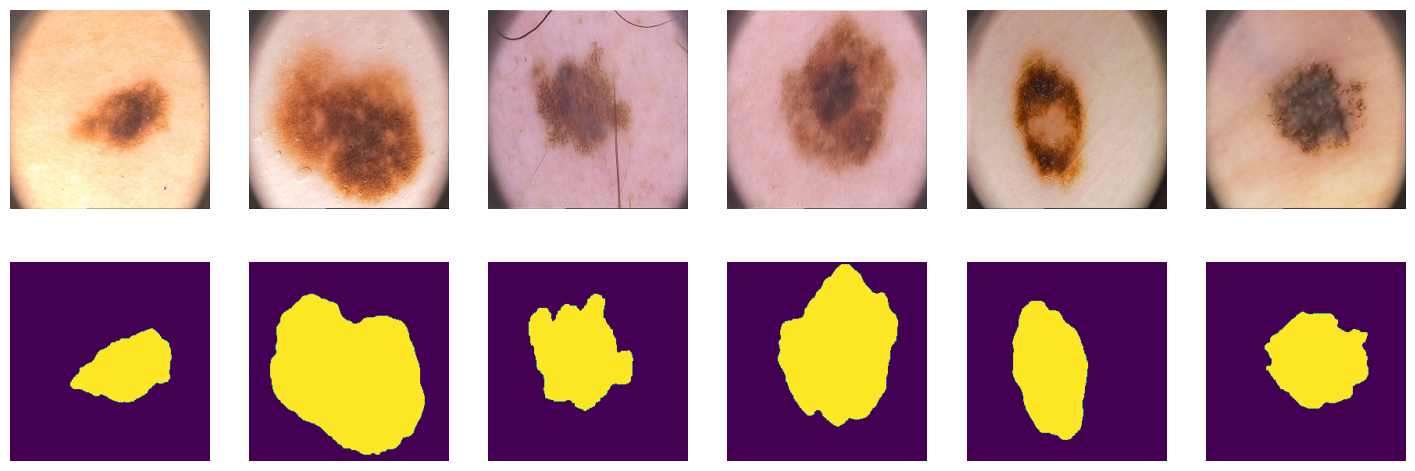

In [10]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

# Implementation of various architectures:

-----------------------------------------------------------------------------------------

# SegNet [2 балла]

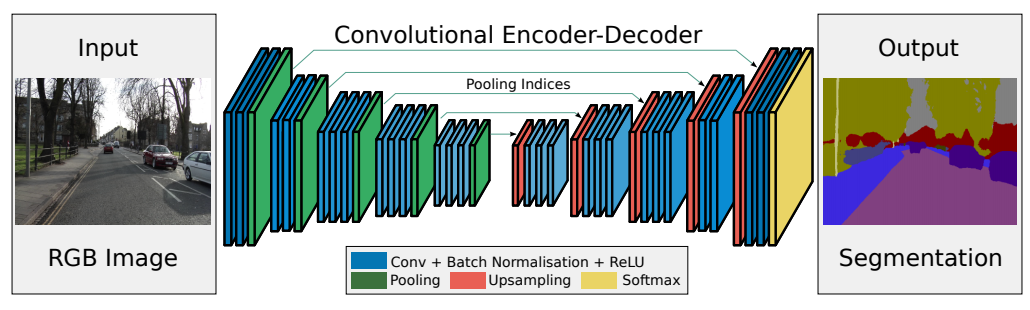

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

## Architecture

* encoder + decoder with last layer as pixelwise classification (multiclass softmax classifier)
* first 13 convolutional layers - from VGG16
* use pretrained classification weights
* each encoder layer has correspondent decoder layer
* don't use fully connected layers in the end of decoder
* each encoder convolution layer is followed by batch normalization and then ReLU activation
* after a block of convolutional layers use max-pooling 2x2 with stride 2
* for encoder store the max-pooling indices
* in decoder use stored indices for upsampling
* decoder convolution layer output has the same number of channels as input of corresponding encoder

In [16]:
class SegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling)
        self.enc_conv0 = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            )
        self.pool0 = nn.MaxPool2d(2, stride=2, return_indices=True) # 256 -> 128
        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            )
        self.pool1 = nn.MaxPool2d(2, stride=2, return_indices=True) # 128 -> 64
        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            )
        self.pool2 = nn.MaxPool2d(2, stride=2, return_indices=True) # 64 -> 32
        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(256, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            )
        self.pool3 = nn.MaxPool2d(2, stride=2, return_indices=True) # 32 -> 16
        self.enc_conv4 = nn.Sequential(
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            )
        self.pool4 = nn.MaxPool2d(2, stride=2, return_indices=True) # 16 -> 8

        # decoder (upsampling)
        self.upsample4 = nn.MaxUnpool2d(2, stride=2) # 16 -> 32
        self.dec_conv4 = nn.Sequential(
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            )
        self.upsample3 = nn.MaxUnpool2d(2, stride=2) # 16 -> 32
        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            )
        self.upsample2 = nn.MaxUnpool2d(2, stride=2) # 32 -> 64
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            )
        self.upsample1 = nn.MaxUnpool2d(2, stride=2) # 64 -> 128
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            )
        self.upsample0 = nn.MaxUnpool2d(2, stride=2) # 128 -> 256
        self.dec_conv0 = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, 3, 1, 1),
            # nn.Sigmoid()
            )

    def forward(self, x):
        # encoder
        e0, pool_indices0 = self.pool0(self.enc_conv0(x))
        e1, pool_indices1 = self.pool1(self.enc_conv1(e0))
        e2, pool_indices2 = self.pool2(self.enc_conv2(e1))
        e3, pool_indices3 = self.pool3(self.enc_conv3(e2))
        e4, pool_indices4 = self.pool4(self.enc_conv4(e3))

        # decoder
        d4 = self.dec_conv4(self.upsample4(e4, pool_indices4))
        d3 = self.dec_conv3(self.upsample3(d4, pool_indices3))
        d2 = self.dec_conv2(self.upsample2(d3, pool_indices2))
        d1 = self.dec_conv1(self.upsample1(d2, pool_indices1))
        d0 = self.dec_conv0(self.upsample0(d1, pool_indices0)) # no activation
        return d0

## Metric

We use IoU metric:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup \text{ prediction }}$

In [17]:
def iou_pytorch(outputs: torch.Tensor, labels: torch.Tensor):
    # You can comment out this line if you are passing tensors of equal shape
    # But if you are passing output from UNet or something it will most probably
    # be with the BATCH x 1 x H x W shape
    outputs = outputs.squeeze(1).byte()  # BATCH x 1 x H x W => BATCH x H x W
    labels = labels.squeeze(1).byte()
    SMOOTH = 1e-8
    intersection = (outputs & labels).float().sum((1, 2))  # Will be zero if Truth=0 or Prediction=0
    union = (outputs | labels).float().sum((1, 2))         # Will be zzero if both are 0

    iou = (intersection + SMOOTH) / (union + SMOOTH)  # We smooth our devision to avoid 0/0

    thresholded = torch.clamp(20 * (iou - 0.5), 0, 10).ceil() / 10  # This is equal to comparing with thresholds

    return thresholded  #

## BCE Loss [1 балл]

<b>From DLS:</b>
$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

This formuly isn't stable due to $\lim_{x\rightarrow0}\log(x)=\infty$. According to [this implementation](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits) we can use an equivalent formula:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right)\ \ \ \ (*)$$

<b>My investigations:</b>

Following the link above we can notice that formula (*) is not final.

"To ensure stability and avoid overflow, the implementation uses this equivalent formulation:
 $$\max(x, 0) - x * z + \log(1 + \exp(-abs(x)))"$$

In [18]:
def bce_loss(y_real, y_pred):
    return torch.sum(torch.max(torch.cat((y_pred, y_pred * 0), dim=1), dim=1, keepdim=True)[0] - y_pred * y_real + torch.log(1 + torch.exp(-torch.abs(y_pred))))

## Training cycle [1 балл]

In [19]:
def train(model, data_tr, data_val,
          opt=optim.Adam, lr=0.0001, loss_fn=bce_loss, epochs=30,
          sched=optim.lr_scheduler.StepLR, sched_params={'step_size':10, 'gamma':0.1}):
    X_val, Y_val = next(iter(data_val))
    optimizer = opt(model.parameters(), lr)
    scheduler = sched(optimizer, **sched_params)
    model.to(device)

    train_loss_history = []
    train_iou_history = []
    val_loss_history = []
    val_iou_history = []
    time_history = []

    for epoch in range(epochs):
        tic = time()
        print('* Epoch %d/%d' % (epoch+1, epochs))

        avg_loss = 0
        avg_iou = 0
        model.train()  # train mode
        for X_batch, Y_batch in data_tr:
            # data to device
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            # set parameter gradients to zero
            optimizer.zero_grad()
            # forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_batch, Y_pred) # forward-pass
            loss.backward() # backward-pass
            optimizer.step() # update weights

            iou = iou_pytorch(torch.sigmoid(Y_pred) > 0.5, Y_batch).mean().item()

            # calculate loss to show the user
            avg_loss += loss / len(data_tr)
            avg_iou += iou / len(data_tr)

            del X_batch
            del Y_batch
            del Y_pred
        toc = time()
        print('train loss: %f\ttrain iou: %f' % (avg_loss, avg_iou))

        train_loss_history.append(avg_loss.item())
        train_iou_history.append(avg_iou)
        time_history.append(toc - tic)

        # show intermediate results
        model.eval() # testing mode
        avg_loss = 0
        avg_iou = 0
        for X_batch, Y_batch in data_val:
            # data to device
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            # forward
            with torch.no_grad():
                Y_pred = model(X_batch)
                loss = loss_fn(Y_batch, Y_pred) # forward-pass
            iou = iou_pytorch(torch.sigmoid(Y_pred) > 0.5, Y_batch).mean().item()
            Y_hat = Y_pred.to('cpu')
            X_val = X_batch.to('cpu')
            # calculate loss to show the user
            avg_loss += loss / len(data_val)
            avg_iou += iou / len(data_val)

            del X_batch
            del Y_batch
            del Y_pred
        val_loss_history.append(avg_loss.item())
        val_iou_history.append(avg_iou)

        # Visualize tools
        clear_output(wait=True)
        for k in range(6):
            plt.subplot(2, 6, k+1)
            plt.imshow(np.rollaxis(X_val[k].numpy(), 0, 3), cmap='gray')
            plt.title('Real')
            plt.axis('off')

            plt.subplot(2, 6, k+7)
            plt.imshow(torch.sigmoid(Y_hat[k, 0]), cmap='gray')
            plt.title('Output')
            plt.axis('off')
        plt.suptitle('%d / %d - loss: %f' % (epoch+1, epochs, avg_loss))
        plt.show()

        scheduler.step()

    return {'train_loss': train_loss_history, 'val_loss': val_loss_history,
            'train_iou': train_iou_history, 'val_iou': val_iou_history,
            'train_time': time_history}

## Predictions [1 балл]

In [20]:
def predict(model, data):
    model.eval()  # testing mode
    Y_pred = [torch.sigmoid(model(X_batch)) > 0.5 for X_batch, _ in data]
    return np.array(Y_pred)

In [21]:
def score_model(model, metric, data):
    model.eval()  # testing mode
    scores = 0
    with torch.no_grad():
        for X_batch, Y_label in data:
            Y_pred = torch.sigmoid(model(X_batch.to(device))) > 0.5
            scores += metric(Y_pred, Y_label.to(device)).mean().item()

    return scores/len(data)

## SegNet with BCE Loss

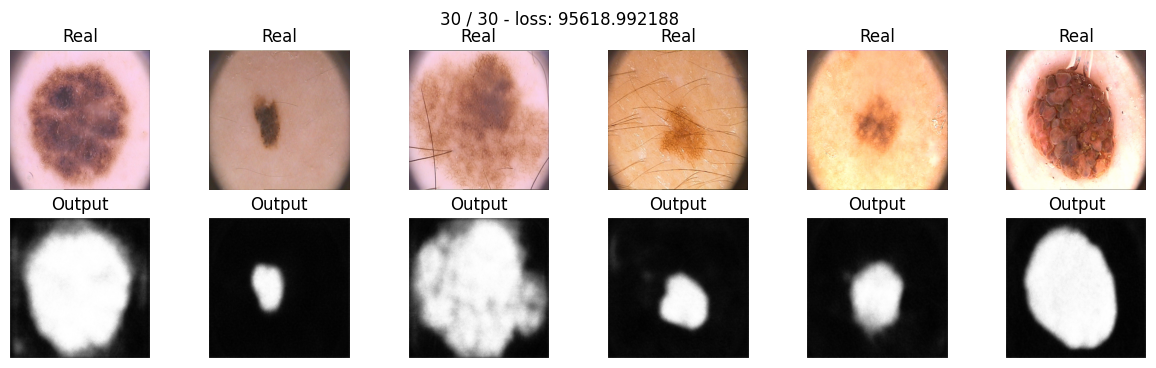

In [ ]:
# del model
model = SegNet()
SegNet_bce = train(model, data_tr, data_val, epochs=30, lr=0.0001, sched_params={'step_size':10, 'gamma':0.1})

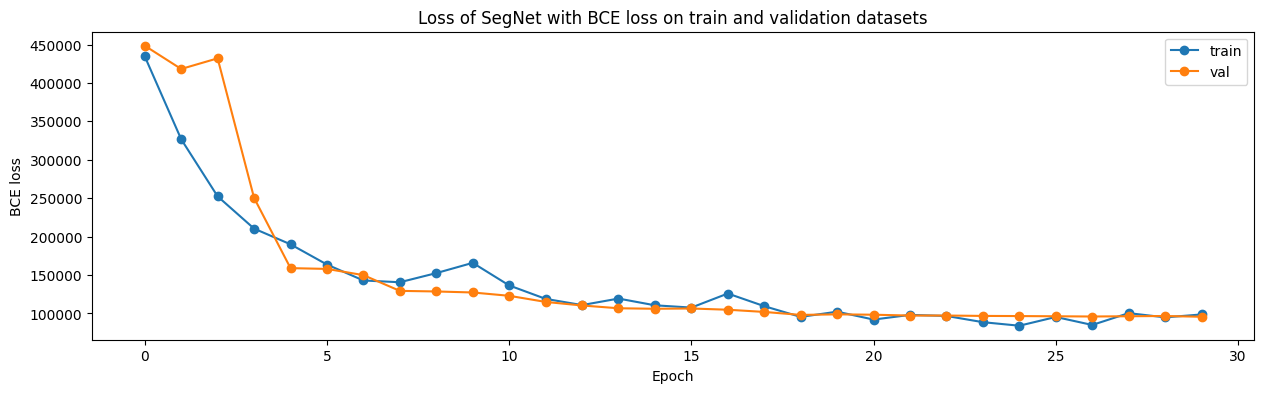

In [ ]:
plt.plot(SegNet_bce['train_loss'][:], marker='o', label='train')
plt.plot(SegNet_bce['val_loss'][:], marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('BCE loss')
plt.title('Loss of SegNet with BCE loss on train and validation datasets')
plt.legend()

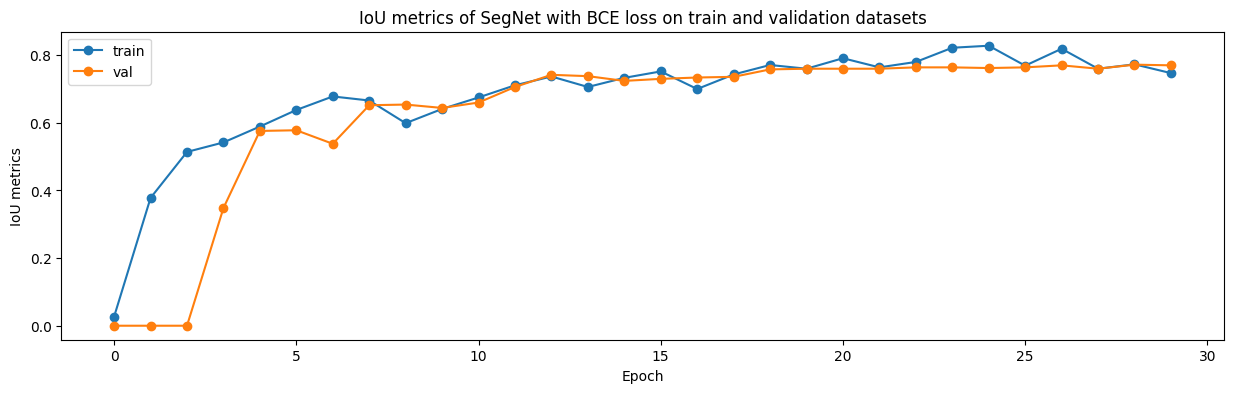

In [ ]:
plt.plot(SegNet_bce['train_iou'][:], marker='o', label='train')
plt.plot(SegNet_bce['val_iou'][:], marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('IoU metrics')
plt.title('IoU metrics of SegNet with BCE loss on train and validation datasets')
plt.legend()

In [ ]:
max(SegNet_bce['val_iou'])

0.7720000267028809

In [ ]:
score = score_model(model.to(device), iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nSegNet_bce_score = ')
    file.write(score.__str__())

score

0.7700000166893005

Model doesn't show overfitting

-----------------------------------------------------------------------------------------

## Дополнительные функции потерь [2 балла]

## Dice Loss
Considering two masks $X$ and $Y$, distance between them is following:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

It's not differentiable, so we use an approximation:

$$\mathcal L_D(X,Y) = 1-\frac{1}{256 \times 256} \times \frac{\sum_i2X_iY_i}{\sum_iX_i+Y_i}.$$

In [22]:
def dice_loss(y_real, y_pred):
    num = torch.sum(y_real * torch.sigmoid(y_pred) * 2.0)
    den = torch.sum(torch.sigmoid(y_pred) + y_real) + 0.00000001
    res = 1 - num / den / 256.0 / 256.0
    return res

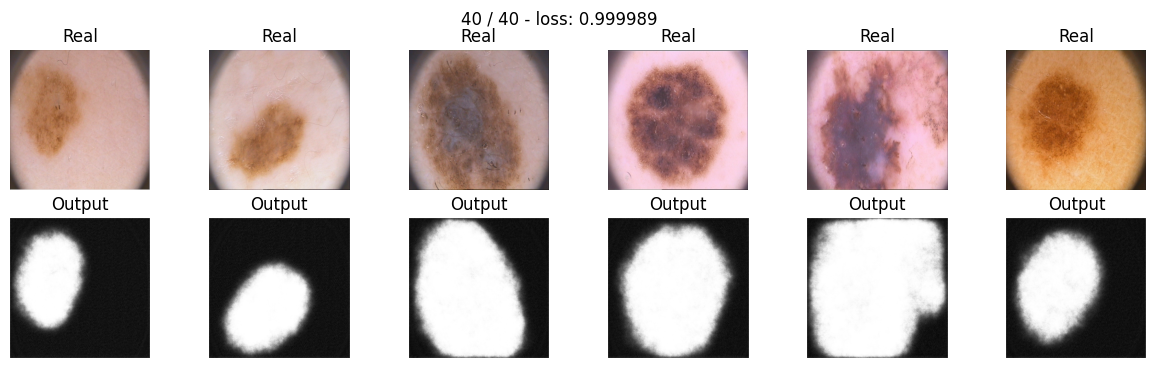

In [ ]:
# del model_dice
model_dice = SegNet()

SegNet_dice = train(model_dice, data_tr, data_val,
                    opt=optim.Adam, loss_fn=dice_loss,
                    epochs=40, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[10, 20, 30], 'gamma':0.1})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

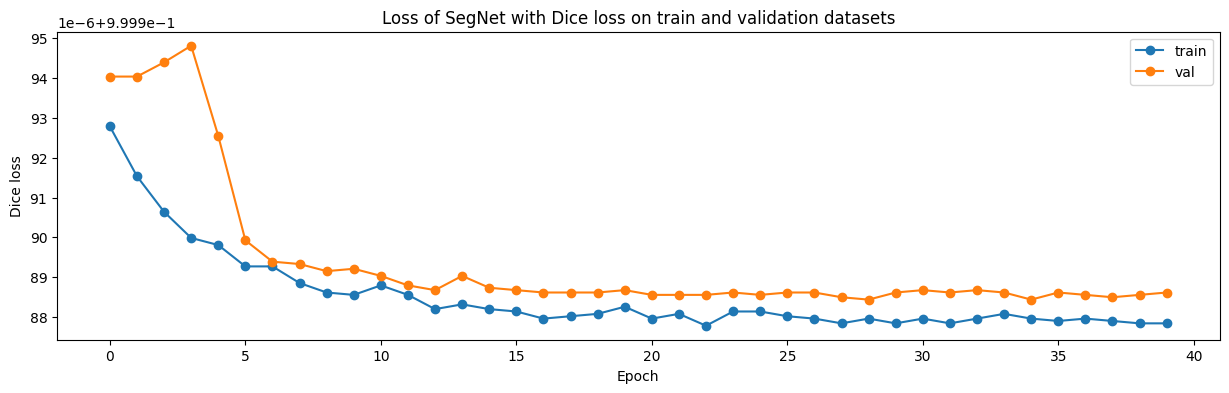

In [ ]:
plt.plot(SegNet_dice['train_loss'][:], marker='o', label='train')
plt.plot(SegNet_dice['val_loss'][:], marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('Dice loss')
plt.title('Loss of SegNet with Dice loss on train and validation datasets')
plt.legend()

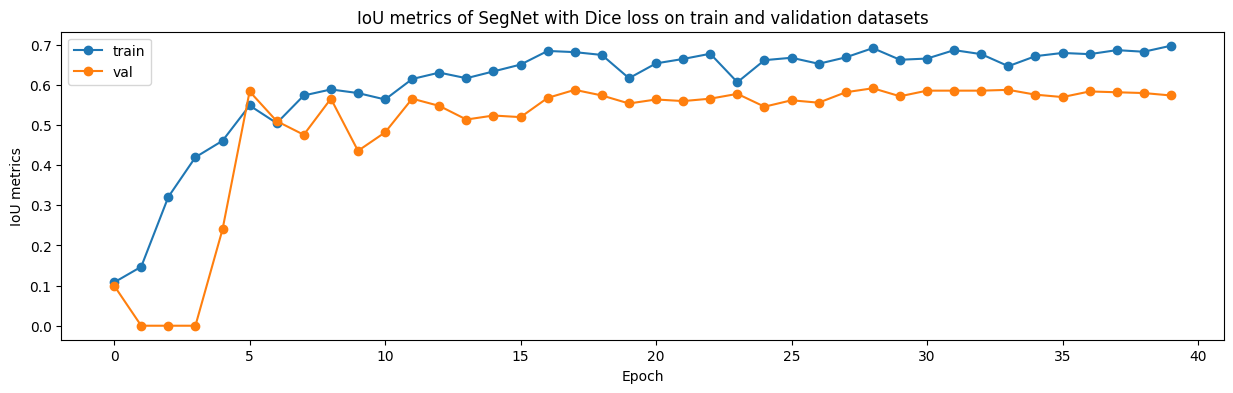

In [ ]:
plt.plot(SegNet_dice['train_iou'][:], marker='o', label='train')
plt.plot(SegNet_dice['val_iou'][:], marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('IoU metrics')
plt.title('IoU metrics of SegNet with Dice loss on train and validation datasets')
plt.legend()

In [ ]:
max(SegNet_dice['val_iou'])

0.5920000195503234

In [ ]:
score = score_model(model_dice, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nSegNet_dice_score = ')
    file.write(score.__str__())

score

0.5740000307559967

## Focal Loss

Focal loss adds weights to classes in BCE loss:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Recent addition:

$$\mathcal L_{focal}(y, \hat y) = -\sum_i \left[\left(1-\sigma(\hat y_i)\right)^\gamma y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

We use $\gamma=2$.

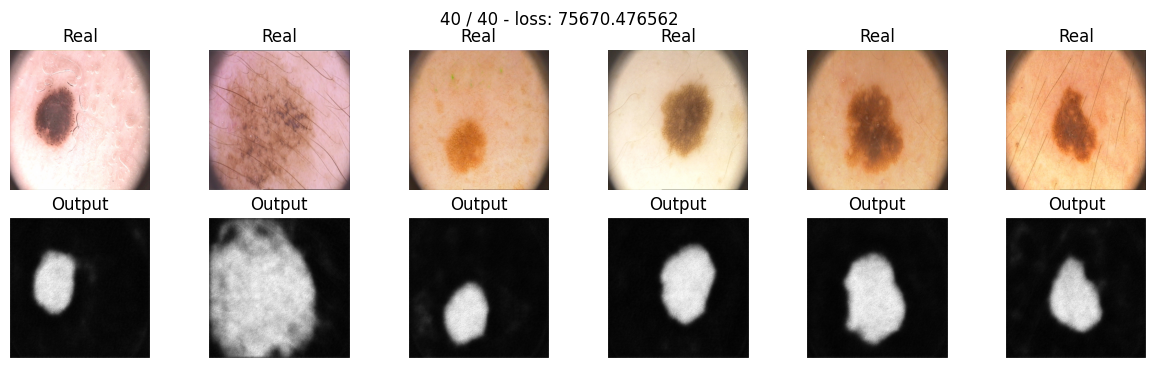

In [ ]:
# del model_focal
model_focal = SegNet()

SegNet_focal = train(model_focal, data_tr, data_val,
                    opt=optim.Adam, loss_fn=focal_loss,
                    epochs=40, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[10, 20, 30], 'gamma':0.1})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

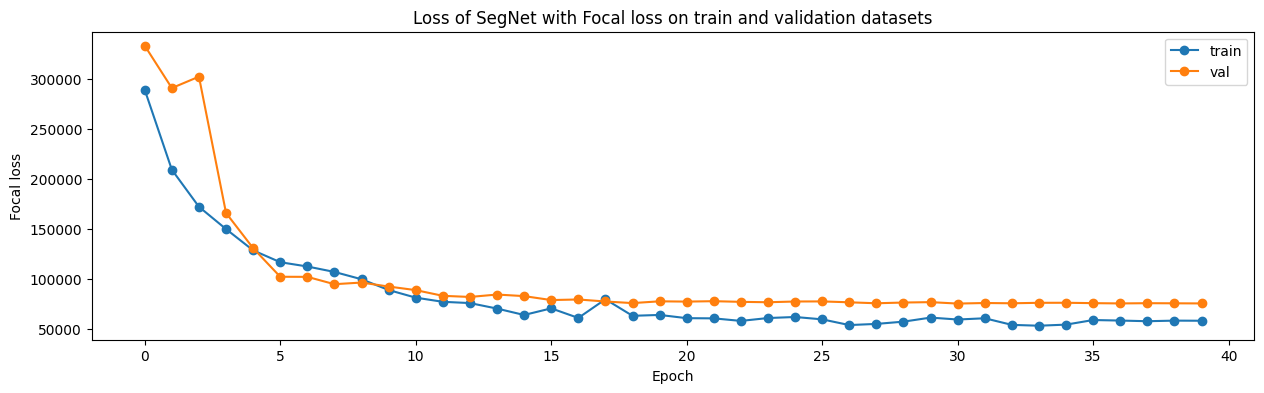

In [ ]:
plt.plot(SegNet_focal['train_loss'][:], marker='o', label='train')
plt.plot(SegNet_focal['val_loss'][:], marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('Focal loss')
plt.title('Loss of SegNet with Focal loss on train and validation datasets')
plt.legend()

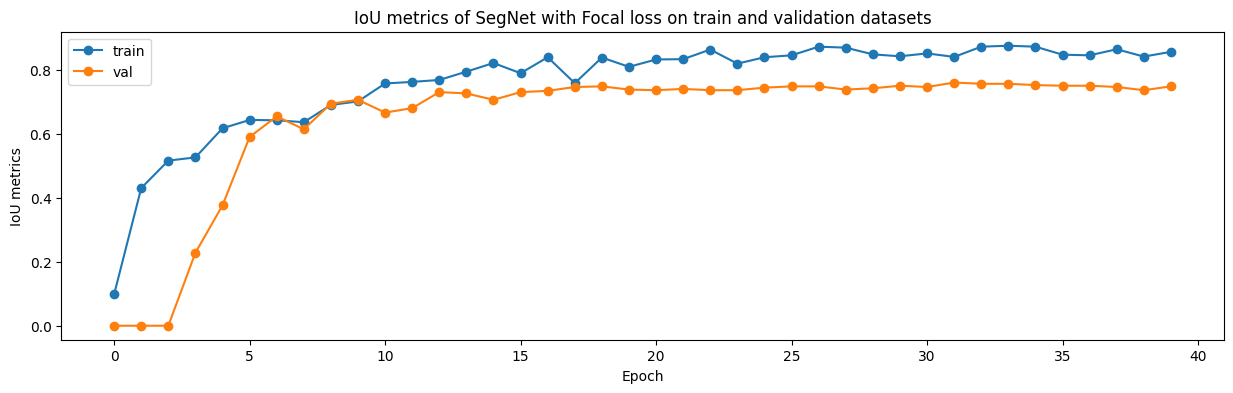

In [ ]:
plt.plot(SegNet_focal['train_iou'][:], marker='o', label='train')
plt.plot(SegNet_focal['val_iou'][:], marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('IoU metrics')
plt.title('IoU metrics of SegNet with Focal loss on train and validation datasets')
plt.legend()

In [ ]:
max(SegNet_focal['val_iou'])

0.7600000381469727

In [ ]:
score = score_model(model_focal, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nSegNet_focal_score = ')
    file.write(score.__str__())

score

0.7480000376701355

----------------------------------------------------------------------------------------------

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее. Кроме тако провести численное сравнение с предыдущими функциями.
Какие варианты?

1) Можно учесть Total Variation
2) Lova
3) BCE но с Soft Targets (что-то типа label-smoothing для многослассовой классификации)
4) Любой другой

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

Так как Тверский лосс очень похож на данные выше, то за него будет проставлено только 3 балла (при условии, если в модели нет ошибок при обучении). Постарайтесь сделать что-то интереснее.

In [24]:
# I use loss from the first paper in the list above
def facial_loss(y_real, y_pred, alpha=0.0001, beta=1.0, gamma=1.0):
    classification_loss = bce_loss(y_real, y_pred)
    y_pred = torch.clamp(torch.sigmoid(y_pred), 0.00000001, 1 - 0.00000001)
    facial_parts_loss = torch.sum((y_real - y_pred) ** 2) / len(y_pred)
    # classification_part = -torch.sum(y_real.T * torch.log(y_pred))
    sparsity_loss = torch.sum(torch.abs(y_pred)) / 256 / 256
    contiguity_loss = torch.sum(torch.abs(y_pred[:, :, 1:, :] - torch.roll(y_pred, 1, 2)[:, :, 1:, :])) / 256 / 256 + \
                      torch.sum(torch.abs(y_pred[:, :, :, 1:] - torch.roll(y_pred, 1, 3)[:, :, :, 1:])) / 256 / 256
    return classification_loss + alpha * (facial_parts_loss + beta * (sparsity_loss + gamma * contiguity_loss))


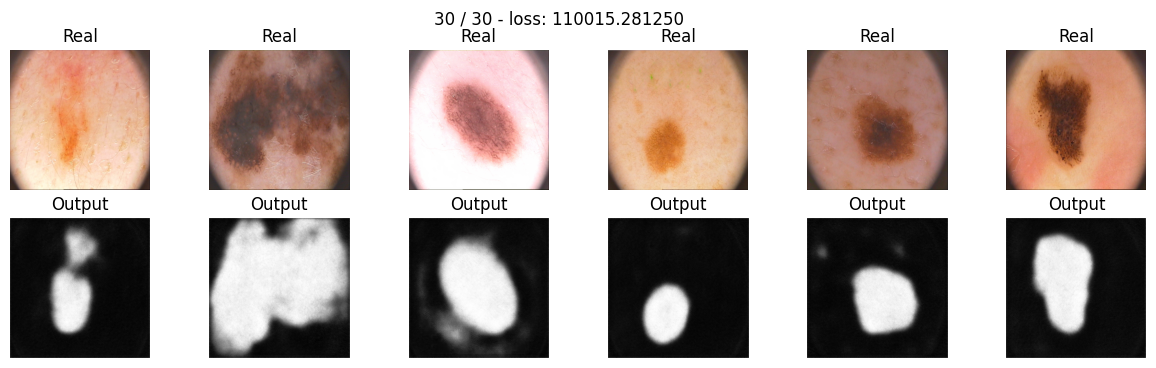

In [25]:
# del model_facial
model_facial = SegNet()

SegNet_facial = train(model_facial, data_tr, data_val,
                    opt=optim.Adam, loss_fn=facial_loss,
                    epochs=30, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[10, 20, 30], 'gamma':0.1})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

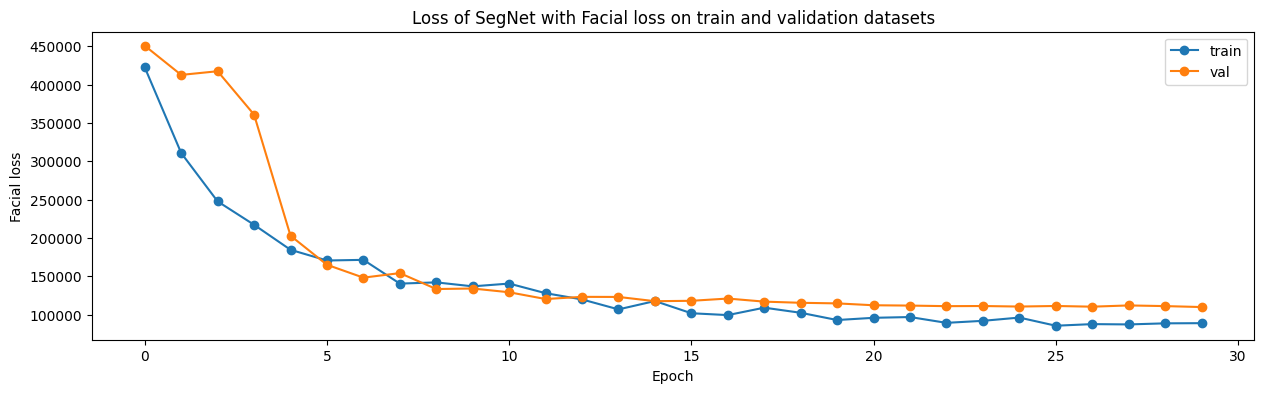

In [28]:
plt.plot(SegNet_facial['train_loss'][:], marker='o', label='train')
plt.plot(SegNet_facial['val_loss'][:], marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('Facial loss')
plt.title('Loss of SegNet with Facial loss on train and validation datasets')
plt.legend()

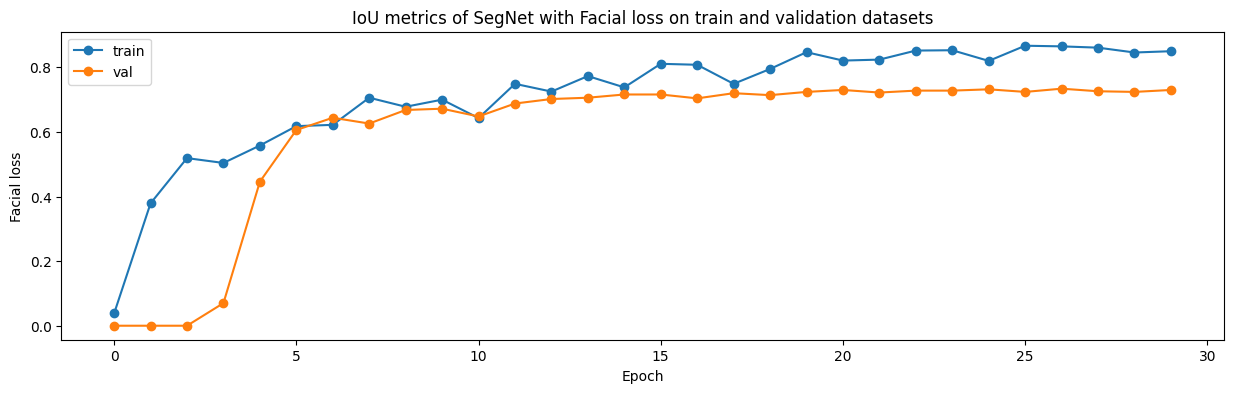

In [29]:
plt.plot(SegNet_facial['train_iou'][:], marker='o', label='train')
plt.plot(SegNet_facial['val_iou'][:], marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('Facial loss')
plt.title('IoU metrics of SegNet with Facial loss on train and validation datasets')
plt.legend()

In [30]:
max(SegNet_facial['val_iou'])

0.734000015258789

In [31]:
score = score_model(model_facial, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nSegNet_facial_score = ')
    file.write(score.__repr__())

score

0.7300000190734863

-----------------------------------------------------------------------------------------

# U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

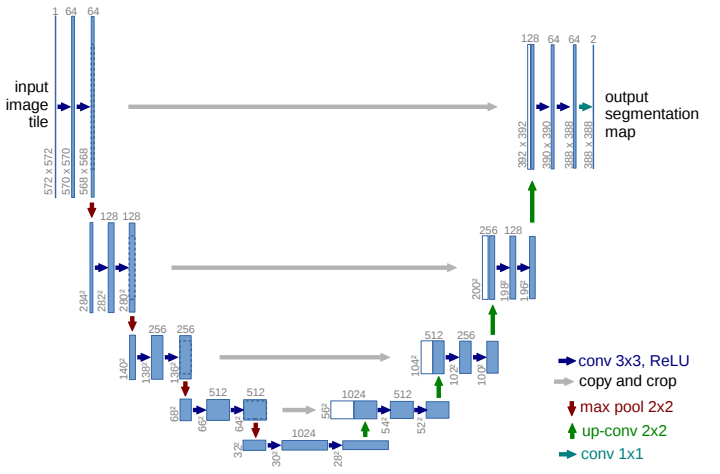

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

## Architecture from the paper

* Consists of a contracting and an expansive paths
* Contracting path is a repeated application of 2 convolutions 3x3 with no padding, each followed by ReLU and 2x2 max-pooling with stride 2
* Each downsampling block doubles the number of channels
* Expansive path is blocks of: upsampling, then 2x2 convolution(up-convolution) with halves the number of channels, concatenation with correspondingly cropped feature map from the contracting path, two 3x3 convolutions+ReLU
* Final layer: 1x1 convolution from 64 channels to number of classes
* It is 23 convolutional layers
* For border regions use extrapolation by mirroring

Authors had images 388x388 and mirror extrapolated them to 572x572. I our case, with 256x256 images, the best way to use this technic is to extrapolate it to 380x380 (add 62 pixels on each side), then we will receive output of 260x260, which we can central crop to 256x256.


In [42]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.preprocess = nn.ReflectionPad2d(padding=94) # 256 -> 444
        self.enc_conv0 = nn.Sequential( # 444 -> 440
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
        )
        self.pool0 = nn.MaxPool2d(2) # 440 -> 220
        self.enc_conv1 = nn.Sequential( # 220 -> 216
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
        )
        self.pool1 = nn.MaxPool2d(2) # 216 -> 108
        self.enc_conv2 = nn.Sequential( # 108 -> 104
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
        )
        self.pool2 = nn.MaxPool2d(2) # 104 -> 52
        self.enc_conv3 = nn.Sequential( # 52 -> 48
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
        )
        self.pool3 = nn.MaxPool2d(2) # 48 -> 24

        # bottleneck
        self.bottleneck_conv = nn.Sequential( # 24 -> 20
            nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
        )

        # decoder (upsampling)
        self.upsample3 = nn.Sequential( # 20 -> 40
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(1024, 512, 2, padding='same'),
            )
        self.dec_conv3 = nn.Sequential( # 40 -> 36
            nn.Conv2d(in_channels=1024, out_channels=512, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
        )
        self.upsample2 = nn.Sequential( # 36 -> 72
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(512, 256, 2, padding='same'),
            )
        self.dec_conv2 = nn.Sequential( # 72 -> 68
            nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
        )
        self.upsample1 = nn.Sequential( # 68 -> 136
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(256, 128, 2, padding='same'),
            )
        self.dec_conv1 = nn.Sequential( # 136 -> 132
            nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
        )
        self.upsample0 = nn.Sequential( # 132 -> 264
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, 2, padding='same'),
            )
        self.dec_conv0 = nn.Sequential( # 264 -> 260
            nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=1, kernel_size=1),
        )

    def forward(self, x):
        # encoder
        e0 = self.enc_conv0(self.preprocess(x))
        e1 = self.enc_conv1(self.pool0(e0))
        e2 = self.enc_conv2(self.pool1(e1))
        e3 = self.enc_conv3(self.pool2(e2))

        # bottleneck
        b = self.bottleneck_conv(self.pool3(e3))

        # decoder
        d30 = self.upsample3(b)
        crop3 = transforms.CenterCrop((d30.shape[-2], d30.shape[-1]))
        d3 = self.dec_conv3(torch.cat((crop3(e3), d30), 1))

        d20 = self.upsample2(d3)
        crop2 = transforms.CenterCrop((d20.shape[-2], d20.shape[-1]))
        d2 = self.dec_conv2(torch.cat((crop2(e2), d20), 1))

        d10 = self.upsample1(d2)
        crop1 = transforms.CenterCrop((d10.shape[-2], d10.shape[-1]))
        d1 = self.dec_conv1(torch.cat((crop1(e1), d10), 1))

        d00 = self.upsample0(d1)
        crop0 = transforms.CenterCrop((d00.shape[-2], d00.shape[-1]))
        d0 = self.dec_conv0(torch.cat((crop0(e0), d00), 1))

        d = transforms.CenterCrop((x.shape[-2], x.shape[-1]))(d0)
        return d

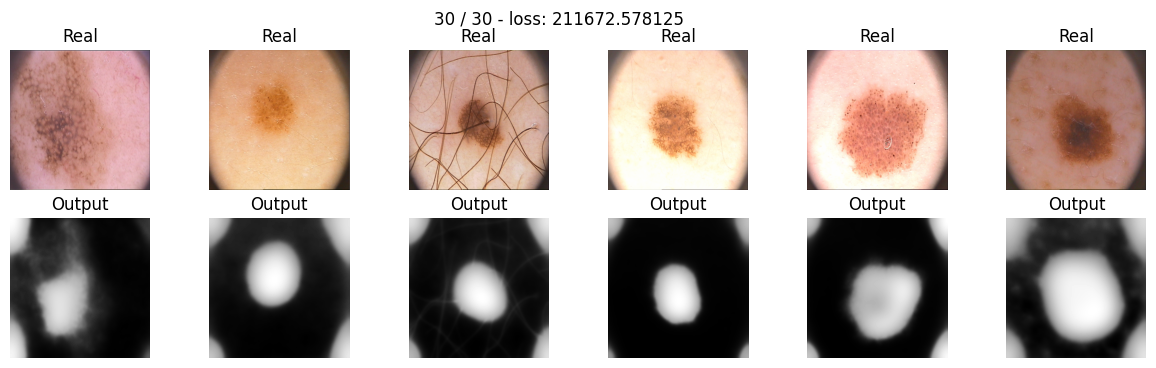

In [43]:
del model_unet_bce
model_unet_bce = UNet()

unet_bce = train(model_unet_bce, data_tr, data_val,
                    opt=optim.Adam, loss_fn=bce_loss,
                    epochs=30, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[5, 10, 20], 'gamma':0.3})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

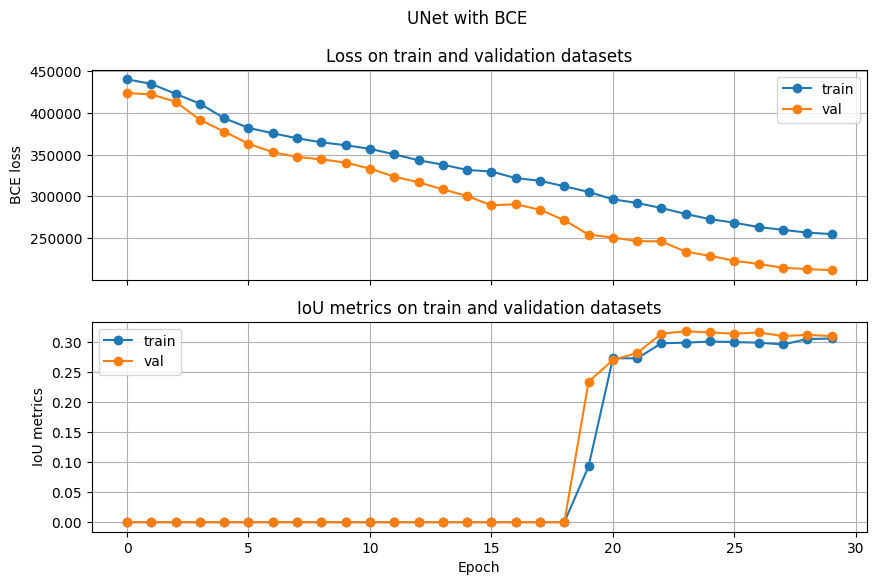

In [44]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(unet_bce['train_loss'][:], marker='o', label='train')
ax[0].plot(unet_bce['val_loss'][:], marker='o', label='val')
# ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('BCE loss')
ax[0].set_title('Loss on train and validation datasets')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(unet_bce['train_iou'][:], marker='o', label='train')
ax[1].plot(unet_bce['val_iou'][:], marker='o', label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('IoU metrics')
ax[1].set_title('IoU metrics on train and validation datasets')
ax[1].grid(True)
ax[1].legend()

plt.suptitle('UNet with BCE')
plt.show()

In [49]:
score = score_model(model_unet_bce, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nUNet_bce_score = ')
    file.write(score.__repr__())

score

0.31000000834465025

In [50]:
max(unet_bce['val_iou'])

0.3180000126361847

We can see that UNet with morror padding doesn't work well for our problem (I willl write more about it in the report). So, let's add simple paddings to convolution layers to have output of the same hight and width as input without using mirror padding.

## UNet without mirror padding

In [34]:
class UNet1(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.enc_conv0 = nn.Sequential(nn.Conv2d(3, 64, 3, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU(),
                                    nn.Conv2d(64, 64, 3, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU())
        self.pool0 = nn.MaxPool2d(2, stride=2)

        self.enc_conv1 = nn.Sequential(
                                    nn.Conv2d(64, 128, 3, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU(),
                                    nn.Conv2d(128, 128, 3, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU())
        self.pool1 = nn.MaxPool2d(2, stride=2)

        self.enc_conv2 = nn.Sequential(
                                    nn.Conv2d(128, 256, 3, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU(),
                                    nn.Conv2d(256, 256, 3, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU())
        self.pool2 = nn.MaxPool2d(2, stride=2)

        self.enc_conv3 = nn.Sequential(
                                    nn.Conv2d(256, 512, 3, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU(),
                                    nn.Conv2d(512, 512, 3, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU())
        self.pool3 = nn.MaxPool2d(2, stride=2)

        # bottleneck
        self.bottleneck_conv = nn.Sequential(
                                    nn.Conv2d(512, 1024, 3, padding=1),
                                    nn.BatchNorm2d(1024),
                                    nn.ReLU(),
                                    nn.Conv2d(1024, 1024, 3, padding=1),
                                    nn.BatchNorm2d(1024),
                                    nn.ReLU())

        # decoder (upsampling)
        self.upsample0 = nn.Sequential(
                                    nn.Upsample(scale_factor=2, mode='nearest'),
                                    nn.Conv2d(1024, 512, 2, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU())
        self.dec_conv0 = nn.Sequential(
                                    nn.Conv2d(1024, 512, 3, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU(),
                                    nn.Conv2d(512, 512, 3, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU())

        self.upsample1 = nn.Sequential(
                                    nn.Upsample(scale_factor=2, mode='nearest'),
                                    nn.Conv2d(512, 256, 2, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU())
        self.dec_conv1 = nn.Sequential(
                                    nn.Conv2d(512, 256, 3, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU(),
                                    nn.Conv2d(256, 256, 3, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU())

        self.upsample2 = nn.Sequential(
                                    nn.Upsample(scale_factor=2, mode='nearest'),
                                    nn.Conv2d(256, 128, 2, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU())
        self.dec_conv2 = nn.Sequential(
                                    nn.Conv2d(256, 128, 3, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU(),
                                    nn.Conv2d(128, 128, 3, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU())
        self.upsample3 = nn.Sequential(
                                    nn.Upsample(scale_factor=2, mode='nearest'),
                                    nn.Conv2d(128, 64, 2, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU())
        self.dec_conv3 = nn.Sequential(
                                    nn.Conv2d(128, 64, 3, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU(),
                                    nn.Conv2d(64, 64, 3, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU(),
                                    nn.BatchNorm2d(64),
                                    nn.Conv2d(64, 1, 1, padding=1))

    def forward(self, x):
        # encoder
        e0 = self.enc_conv0(x)
        e1 = self.enc_conv1(self.pool0(e0))
        e2 = self.enc_conv2(self.pool1(e1))
        e3 = self.enc_conv3(self.pool2(e2))

        # bottleneck
        b = self.bottleneck_conv(self.pool3(e3))

        # decoder
        up_b = self.upsample0(b)

        trans = transforms.CenterCrop((up_b.shape[-2], up_b.shape[-1]))
        d0 = self.dec_conv0(torch.cat((up_b, trans(e3)),1))

        up_d0 = self.upsample1(d0)
        trans = transforms.CenterCrop((up_d0.shape[-2], up_d0.shape[-1]))
        d1 = self.dec_conv1(torch.cat((up_d0, trans(e2)),1))

        up_d1 = self.upsample2(d1)
        trans = transforms.CenterCrop((up_d1.shape[-2], up_d1.shape[-1]))
        d2 = self.dec_conv2(torch.cat((up_d1, trans(e1)),1))

        up_d2 = self.upsample3(d2)
        trans = transforms.CenterCrop((up_d2.shape[-2], up_d2.shape[-1]))
        d3 = self.dec_conv3(torch.cat((up_d2, trans(e0)),1))

        trans = transforms.CenterCrop((x.shape[-2], x.shape[-1]))
        out = trans(d3)
        return out

### BCE Loss

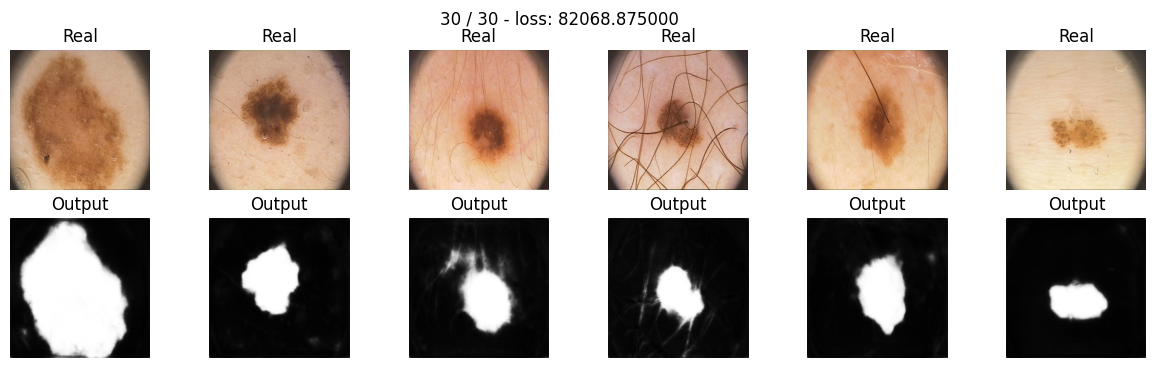

In [46]:
# del model_unet1_bce
model_unet1_bce = UNet1()

unet1_bce = train(model_unet1_bce, data_tr, data_val,
                    opt=optim.Adam, loss_fn=bce_loss,
                    epochs=30, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[5, 10, 20], 'gamma':0.3})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

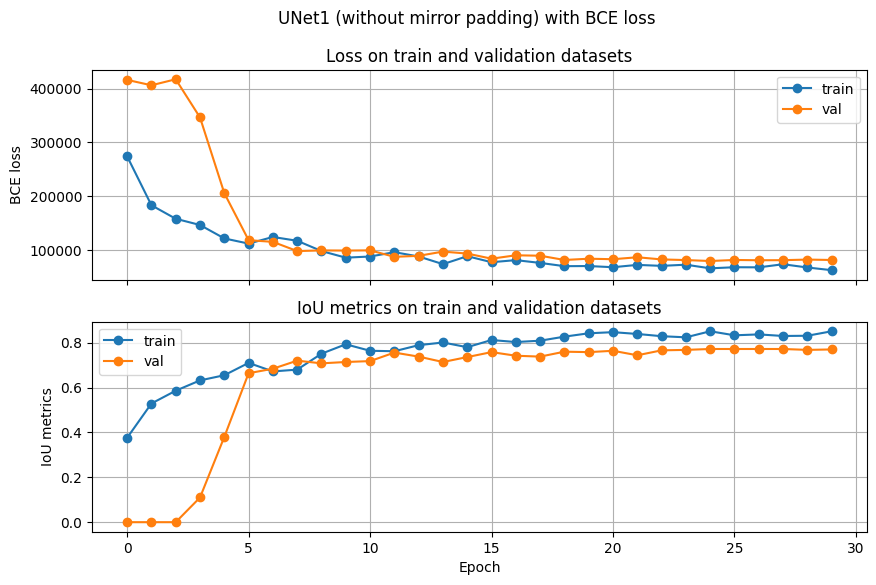

In [47]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(unet1_bce['train_loss'][:], marker='o', label='train')
ax[0].plot(unet1_bce['val_loss'][:], marker='o', label='val')
# ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('BCE loss')
ax[0].set_title('Loss on train and validation datasets')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(unet1_bce['train_iou'][:], marker='o', label='train')
ax[1].plot(unet1_bce['val_iou'][:], marker='o', label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('IoU metrics')
ax[1].set_title('IoU metrics on train and validation datasets')
ax[1].grid(True)
ax[1].legend()

plt.suptitle('UNet1 (without mirror padding) with BCE loss')
plt.show()

In [52]:
score = score_model(model_unet1_bce, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nUNet1_bce_score = ')
    file.write(score.__repr__())

score

0.7700000047683716

In [54]:
max(unet1_bce['val_iou'])

0.7720000624656678

### Dice Loss

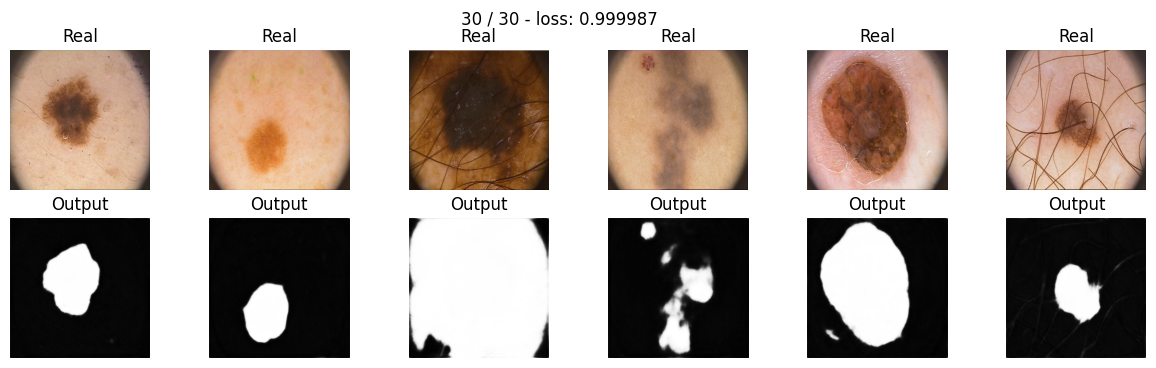

In [65]:
# del model_unet1_dice
model_unet1_dice = UNet1()

unet1_dice = train(model_unet1_dice, data_tr, data_val,
                    opt=optim.Adam, loss_fn=dice_loss,
                    epochs=30, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[5, 10, 20], 'gamma':0.3})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

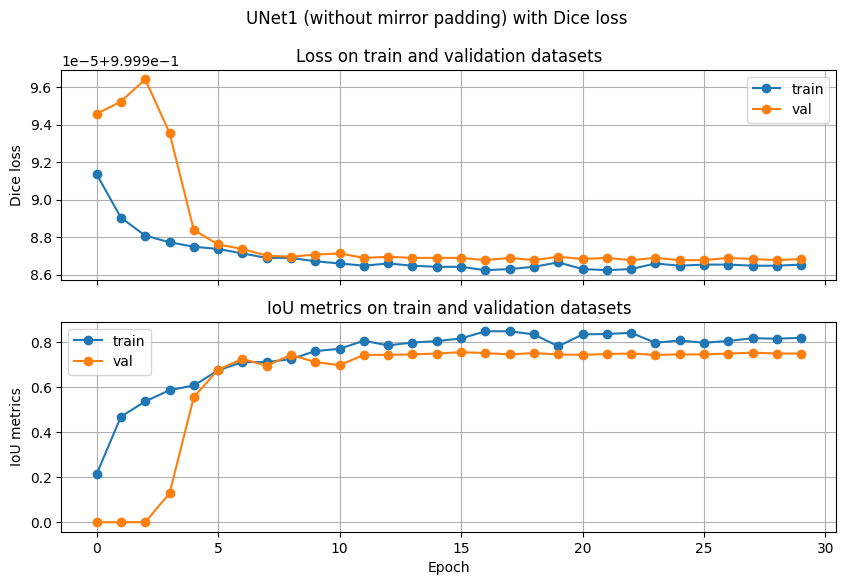

In [66]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(unet1_dice['train_loss'][:], marker='o', label='train')
ax[0].plot(unet1_dice['val_loss'][:], marker='o', label='val')
# ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Dice loss')
ax[0].set_title('Loss on train and validation datasets')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(unet1_dice['train_iou'][:], marker='o', label='train')
ax[1].plot(unet1_dice['val_iou'][:], marker='o', label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('IoU metrics')
ax[1].set_title('IoU metrics on train and validation datasets')
ax[1].grid(True)
ax[1].legend()

plt.suptitle('UNet1 (without mirror padding) with Dice loss')
plt.show()

In [68]:
score = score_model(model_unet1_dice, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nUNet1_dice_score = ')
    file.write(score.__repr__())

score

0.7500000238418579

In [69]:
max(unet1_dice['val_iou'])

0.756000006198883

### Focal Loss

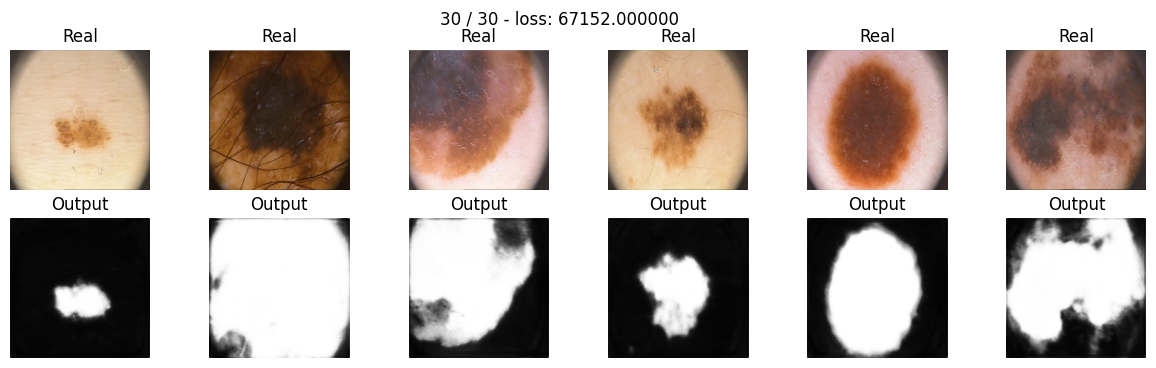

In [60]:
# del model_unet1_focal
model_unet1_focal = UNet1()

unet1_focal = train(model_unet1_focal, data_tr, data_val,
                    opt=optim.Adam, loss_fn=focal_loss,
                    epochs=30, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[5, 10, 20], 'gamma':0.3})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

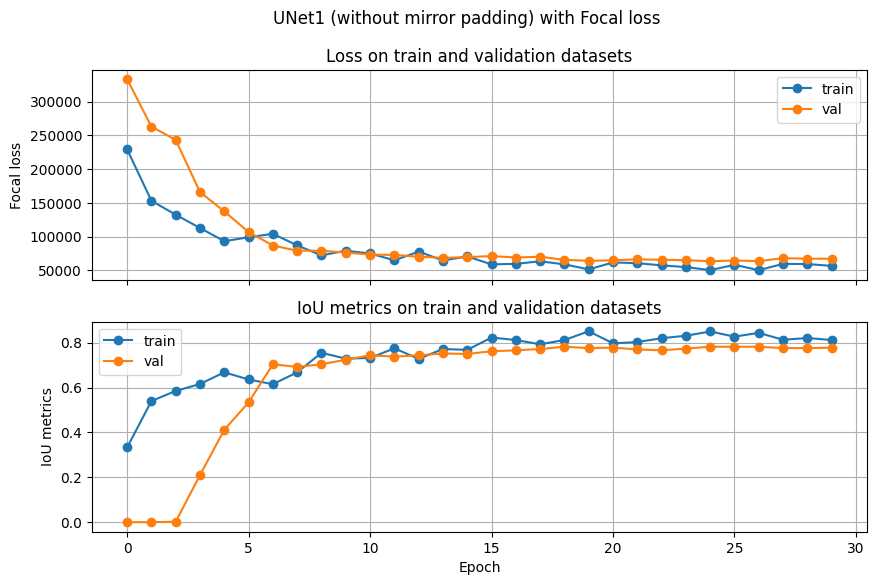

In [61]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(unet1_focal['train_loss'][:], marker='o', label='train')
ax[0].plot(unet1_focal['val_loss'][:], marker='o', label='val')
# ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Focal loss')
ax[0].set_title('Loss on train and validation datasets')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(unet1_focal['train_iou'][:], marker='o', label='train')
ax[1].plot(unet1_focal['val_iou'][:], marker='o', label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('IoU metrics')
ax[1].set_title('IoU metrics on train and validation datasets')
ax[1].grid(True)
ax[1].legend()

plt.suptitle('UNet1 (without mirror padding) with Focal loss')
plt.show()

In [63]:
score = score_model(model_unet1_focal, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nUNet1_focal_score = ')
    file.write(score.__repr__())

score

0.778000020980835

In [64]:
max(unet1_focal['val_iou'])

0.7820000290870667

### Facial Loss

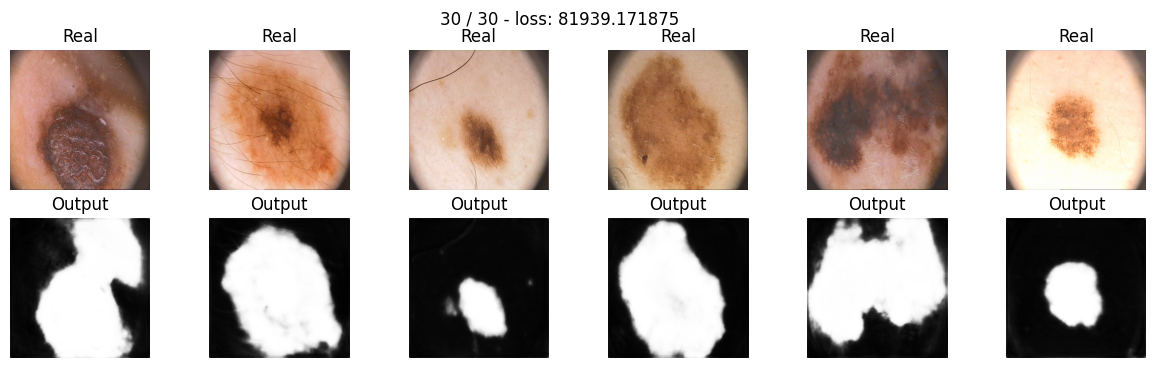

In [55]:
# del model_unet1_facial
model_unet1_facial = UNet1()

unet1_facial = train(model_unet1_facial, data_tr, data_val,
                    opt=optim.Adam, loss_fn=facial_loss,
                    epochs=30, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[5, 10, 20], 'gamma':0.3})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

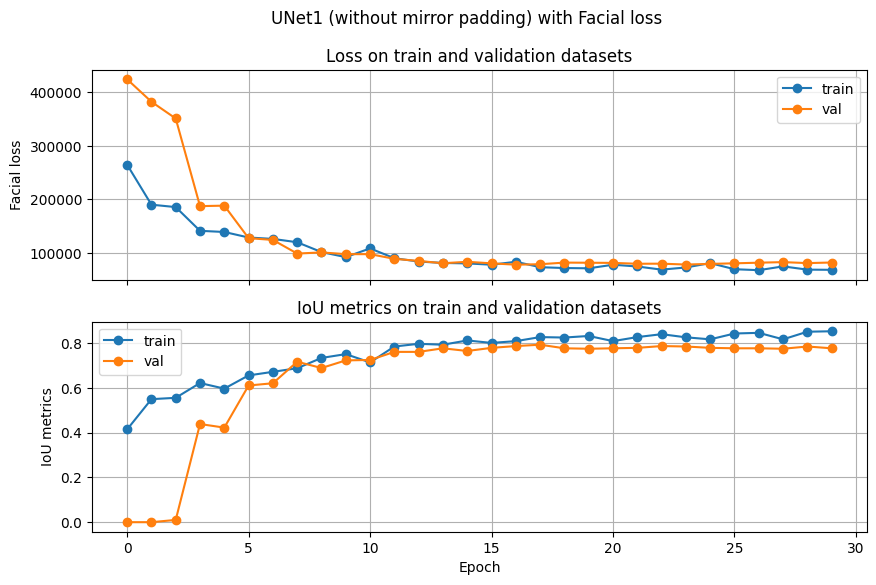

In [56]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(unet1_facial['train_loss'][:], marker='o', label='train')
ax[0].plot(unet1_facial['val_loss'][:], marker='o', label='val')
# ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Facial loss')
ax[0].set_title('Loss on train and validation datasets')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(unet1_facial['train_iou'][:], marker='o', label='train')
ax[1].plot(unet1_facial['val_iou'][:], marker='o', label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('IoU metrics')
ax[1].set_title('IoU metrics on train and validation datasets')
ax[1].grid(True)
ax[1].legend()

plt.suptitle('UNet1 (without mirror padding) with Facial loss')
plt.show()

In [58]:
score = score_model(model_unet1_facial, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nUNet1_facial_score = ')
    file.write(score.__repr__())

score

0.7760000228881836

In [59]:
max(unet1_facial['val_iou'])

0.7920000433921814

## UNet with transpose convolution

Новая модель путем изменения типа пулинга:

 **Max-Pooling** for the downsampling and **nearest-neighbor Upsampling** for the upsampling.

Down-sampling:

        conv = nn.Conv2d(3, 64, 3, padding=1)
        pool = nn.MaxPool2d(3, 2, padding=1)

Up-Sampling

        upsample = nn.Upsample(32)
        conv = nn.Conv2d(64, 64, 3, padding=1)

Замените max-pooling на convolutions с stride=2 и upsampling на transpose-convolutions с stride=2.


In [36]:
class UNet2(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc_conv0 = nn.Sequential(nn.Conv2d(3, 64, 3, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU(),
                                    nn.Conv2d(64, 64, 3, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU())
        self.pool0 = nn.Conv2d(64, 64, 3, stride=2)

        self.enc_conv1 = nn.Sequential(
                                    nn.Conv2d(64, 128, 3, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU(),
                                    nn.Conv2d(128, 128, 3, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU())
        self.pool1 = nn.Conv2d(128, 128, 3, stride=2)

        self.enc_conv2 = nn.Sequential(
                                    nn.Conv2d(128, 256, 3, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU(),
                                    nn.Conv2d(256, 256, 3, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU())
        self.pool2 = nn.Conv2d(256, 256, 3, stride=2)

        self.enc_conv3 = nn.Sequential(
                                    nn.Conv2d(256, 512, 3, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU(),
                                    nn.Conv2d(512, 512, 3, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU())
        self.pool3 = nn.Conv2d(512, 512, 3, stride=2)

        # bottleneck
        self.bottleneck_conv = nn.Sequential(
                                    nn.Conv2d(512, 1024, 3, padding=1),
                                    nn.BatchNorm2d(1024),
                                    nn.ReLU(),
                                    nn.Conv2d(1024, 1024, 3, padding=1),
                                    nn.BatchNorm2d(1024),
                                    nn.ReLU())

        # decoder (upsampling)
        self.upsample0 = nn.Sequential(
                                    nn.ConvTranspose2d(1024, 1024, 3, stride=2, padding=1),
                                    nn.Conv2d(1024, 512, 2, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU())
        self.dec_conv0 = nn.Sequential(
                                    nn.Conv2d(1024, 512, 3, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU(),
                                    nn.Conv2d(512, 512, 3, padding=1),
                                    nn.BatchNorm2d(512),
                                    nn.ReLU())

        self.upsample1 = nn.Sequential(
                                    nn.ConvTranspose2d(512, 512, 3, stride=2, padding=1),
                                    nn.Conv2d(512, 256, 2, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU())
        self.dec_conv1 = nn.Sequential(
                                    nn.Conv2d(512, 256, 3, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU(),
                                    nn.Conv2d(256, 256, 3, padding=1),
                                    nn.BatchNorm2d(256),
                                    nn.ReLU())

        self.upsample2 = nn.Sequential(
                                    nn.ConvTranspose2d(256, 256, 3, stride=2, padding=1),
                                    nn.Conv2d(256, 128, 2, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU())
        self.dec_conv2 = nn.Sequential(
                                    nn.Conv2d(256, 128, 3, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU(),
                                    nn.Conv2d(128, 128, 3, padding=1),
                                    nn.BatchNorm2d(128),
                                    nn.ReLU())
        self.upsample3 = nn.Sequential(
                                    nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1),
                                    nn.Conv2d(128, 64, 2, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU())
        self.dec_conv3 = nn.Sequential(
                                    nn.Conv2d(128, 64, 3, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU(),
                                    nn.Conv2d(64, 64, 3, padding=1),
                                    nn.BatchNorm2d(64),
                                    nn.ReLU(),
                                    nn.BatchNorm2d(64),
                                    nn.Conv2d(64, 1, 1, padding=1))

    def forward(self, x):
        # encoder
        e0 = self.enc_conv0(x)
        e1 = self.enc_conv1(self.pool0(e0))
        e2 = self.enc_conv2(self.pool1(e1))
        e3 = self.enc_conv3(self.pool2(e2))

        # bottleneck
        b = self.bottleneck_conv(self.pool3(e3))

        # decoder
        up_b = self.upsample0(b)

        trans = transforms.CenterCrop((up_b.shape[-2], up_b.shape[-1]))
        d0 = self.dec_conv0(torch.cat((up_b, trans(e3)),1))

        up_d0 = self.upsample1(d0)
        trans = transforms.CenterCrop((up_d0.shape[-2], up_d0.shape[-1]))
        d1 = self.dec_conv1(torch.cat((up_d0, trans(e2)),1))

        up_d1 = self.upsample2(d1)
        trans = transforms.CenterCrop((up_d1.shape[-2], up_d1.shape[-1]))
        d2 = self.dec_conv2(torch.cat((up_d1, trans(e1)),1))

        up_d2 = self.upsample3(d2)
        trans = transforms.CenterCrop((up_d2.shape[-2], up_d2.shape[-1]))
        d3 = self.dec_conv3(torch.cat((up_d2, trans(e0)),1))

        trans = transforms.CenterCrop((x.shape[-2], x.shape[-1]))
        out = trans(d3)
        return out

### BCE Loss

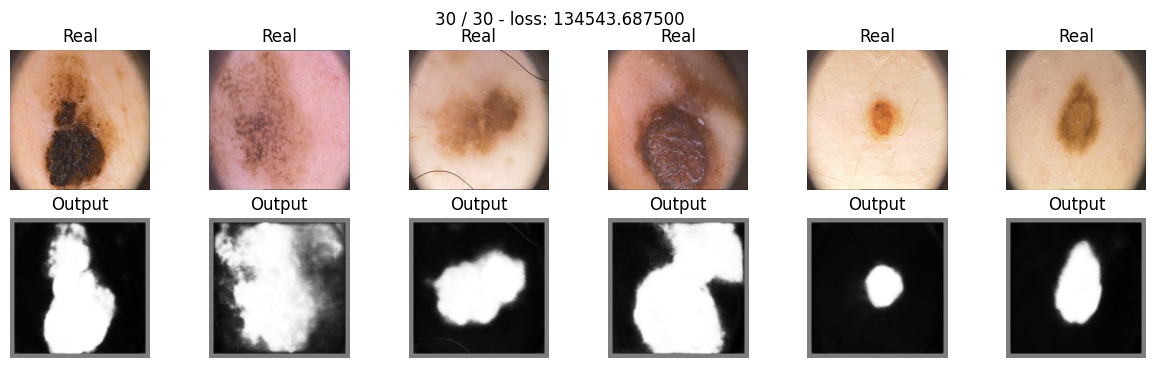

In [71]:
# del model_unet1_bce
model_unet2_bce = UNet2()

unet2_bce = train(model_unet2_bce, data_tr, data_val,
                    opt=optim.Adam, loss_fn=bce_loss,
                    epochs=30, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[5, 10, 20], 'gamma':0.3})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

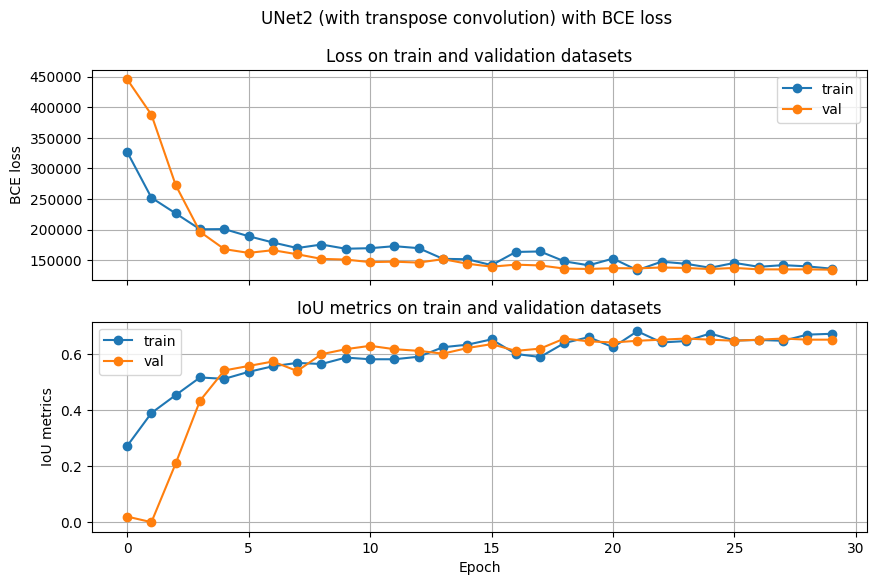

In [72]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(unet2_bce['train_loss'][:], marker='o', label='train')
ax[0].plot(unet2_bce['val_loss'][:], marker='o', label='val')
# ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('BCE loss')
ax[0].set_title('Loss on train and validation datasets')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(unet2_bce['train_iou'][:], marker='o', label='train')
ax[1].plot(unet2_bce['val_iou'][:], marker='o', label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('IoU metrics')
ax[1].set_title('IoU metrics on train and validation datasets')
ax[1].grid(True)
ax[1].legend()

plt.suptitle('UNet2 (with transpose convolution) with BCE loss')
plt.show()

In [74]:
score = score_model(model_unet2_bce, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nUNet2_bce_score = ')
    file.write(score.__repr__())

score

0.6520000338554383

In [75]:
max(unet2_bce['val_iou'])

0.656000030040741

### Dice Loss

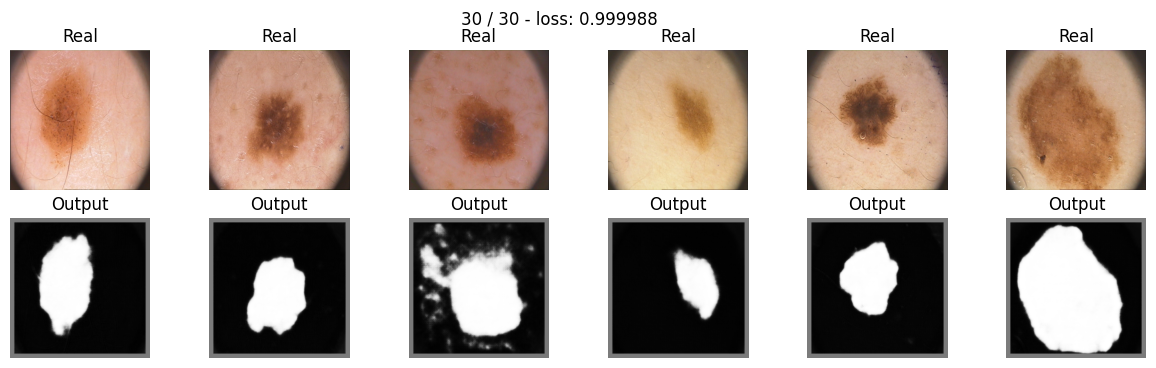

In [76]:
# del model_unet1_dice
model_unet2_dice = UNet2()

unet2_dice = train(model_unet2_dice, data_tr, data_val,
                    opt=optim.Adam, loss_fn=dice_loss,
                    epochs=30, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[5, 10, 20], 'gamma':0.3})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

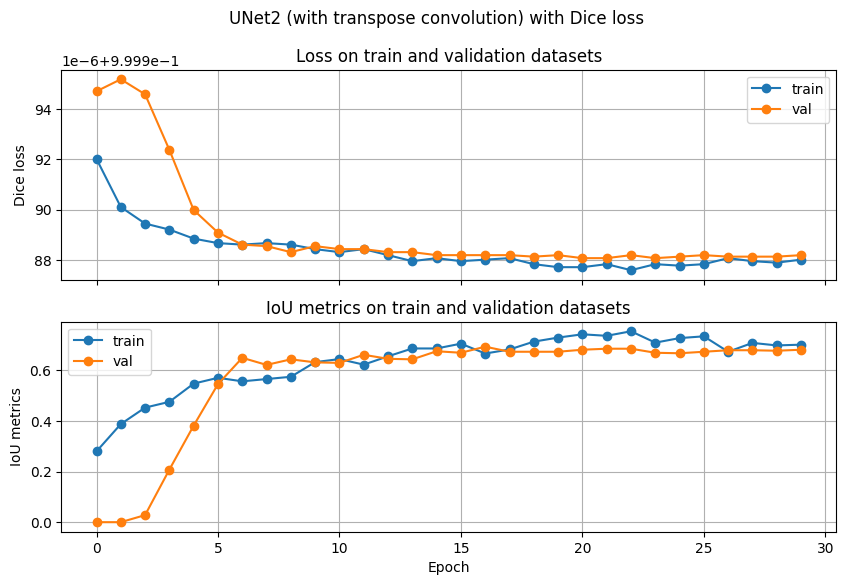

In [77]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(unet2_dice['train_loss'][:], marker='o', label='train')
ax[0].plot(unet2_dice['val_loss'][:], marker='o', label='val')
# ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Dice loss')
ax[0].set_title('Loss on train and validation datasets')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(unet2_dice['train_iou'][:], marker='o', label='train')
ax[1].plot(unet2_dice['val_iou'][:], marker='o', label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('IoU metrics')
ax[1].set_title('IoU metrics on train and validation datasets')
ax[1].grid(True)
ax[1].legend()

plt.suptitle('UNet2 (with transpose convolution) with Dice loss')
plt.show()

In [78]:
with open('models_results.txt', 'a') as file:
    file.write('\nUNet2_dice = ')
    file.write(unet2_dice.__repr__())

with open('models_weights.txt', 'a') as file:
    file.write('\nUNet2_dice_state_dict = ')
    file.write(model_unet2_dice.state_dict.__repr__())

In [79]:
score = score_model(model_unet2_dice, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nUNet2_dice_score = ')
    file.write(score.__repr__())

score

0.6820000290870667

In [80]:
max(unet2_dice['val_iou'])

0.6940000414848329

### Facial Loss

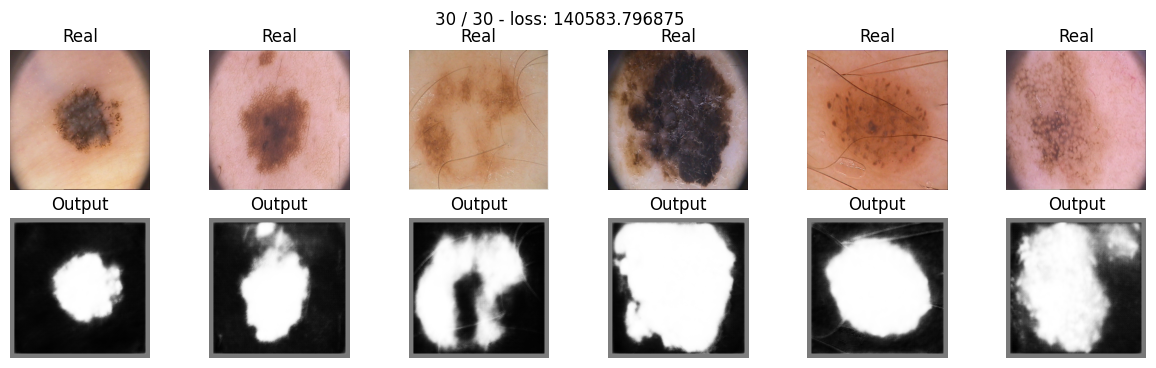

In [86]:
# del model_unet1_facial
model_unet2_facial = UNet2()

unet2_facial = train(model_unet2_facial, data_tr, data_val,
                    opt=optim.Adam, loss_fn=facial_loss,
                    epochs=30, lr=0.0001,
                    # sched=optim.lr_scheduler.MultiStepLR, sched_params={'milestones':[5, 10, 20], 'gamma':0.3})
                    sched=optim.lr_scheduler.StepLR, sched_params={'step_size': 4, 'gamma': 0.5})

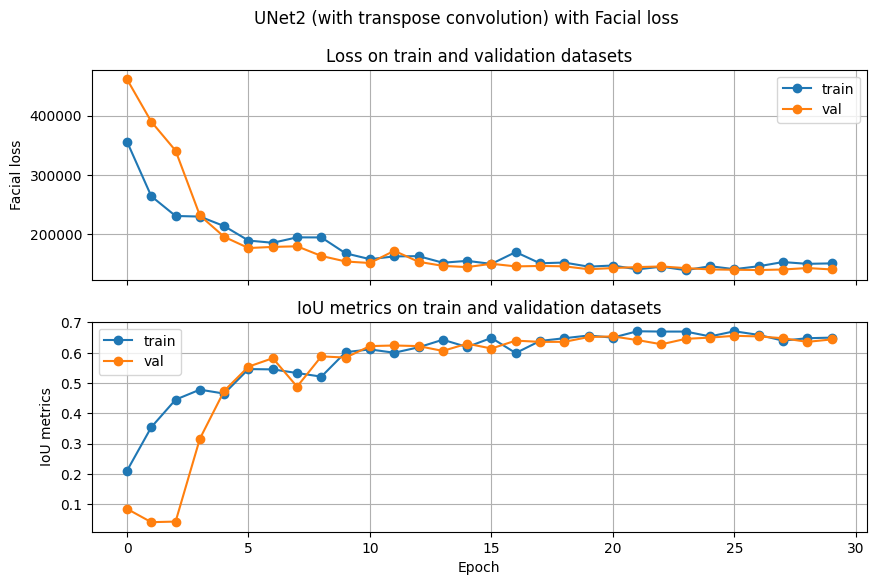

In [87]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(unet2_facial['train_loss'][:], marker='o', label='train')
ax[0].plot(unet2_facial['val_loss'][:], marker='o', label='val')
# ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Facial loss')
ax[0].set_title('Loss on train and validation datasets')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(unet2_facial['train_iou'][:], marker='o', label='train')
ax[1].plot(unet2_facial['val_iou'][:], marker='o', label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('IoU metrics')
ax[1].set_title('IoU metrics on train and validation datasets')
ax[1].grid(True)
ax[1].legend()

plt.suptitle('UNet2 (with transpose convolution) with Facial loss')
plt.show()

In [89]:
score = score_model(model_unet2_facial, iou_pytorch, data_val)

with open('models_results.txt', 'a') as file:
    file.write('\nUNet2_facial_score = ')
    file.write(score.__repr__())

score

0.6440000176429749

In [90]:
max(unet2_facial['val_iou'])

0.656000018119812

# Отчет (6 баллов):

## 1. One algorithm, four losses
We already saw how loss and IoU change during the learning process of different algorithms with different losses. Now, let's compare them with each other.

First, we need to understand which loss is the best for each algorithm. We cant' compare different losses numerically, only by general learning trajectory.That's why I drew a separate graph for each loss. But we can compare IoU, so further there are two graphs (for train and validation data) showing IoU with different losses.

### SegNet

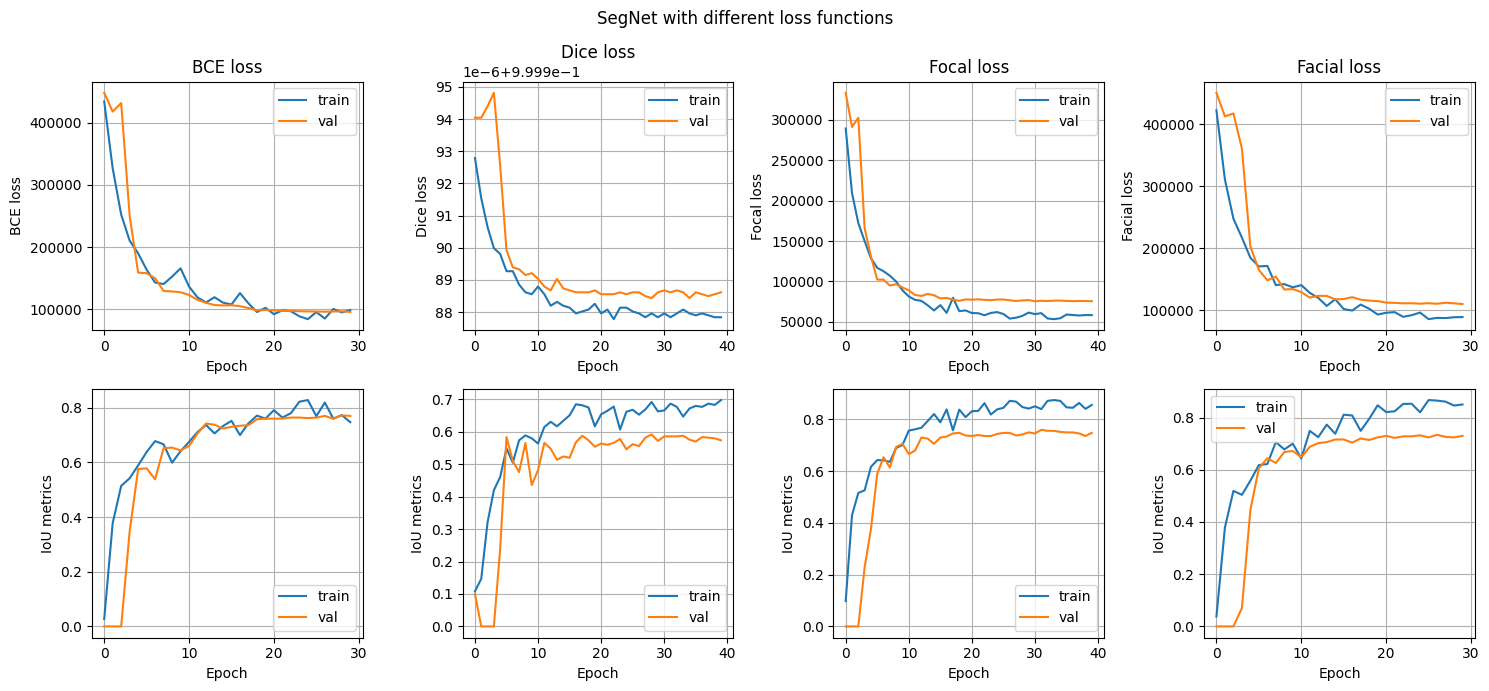

In [3]:
import matplotlib.pyplot as plt

while True:
    fig, ax = plt.subplots(2, 4, figsize=(15, 7))
    ax[0, 0].plot(SegNet_bce['train_loss'][:], marker='', label='train')
    ax[0, 0].plot(SegNet_bce['val_loss'][:], marker='', label='val')
    ax[0, 0].set_xlabel('Epoch')
    ax[0, 0].set_ylabel('BCE loss')
    ax[0, 0].set_title('BCE loss')
    ax[0, 0].grid(True)
    ax[0, 0].legend()

    ax[0, 1].plot(SegNet_dice['train_loss'][:], marker='', label='train')
    ax[0, 1].plot(SegNet_dice['val_loss'][:], marker='', label='val')
    ax[0, 1].set_xlabel('Epoch')
    ax[0, 1].set_ylabel('Dice loss')
    ax[0, 1].set_title('Dice loss')
    ax[0, 1].grid(True)
    ax[0, 1].legend()

    ax[0, 2].plot(SegNet_focal['train_loss'][:], marker='', label='train')
    ax[0, 2].plot(SegNet_focal['val_loss'][:], marker='', label='val')
    ax[0, 2].set_xlabel('Epoch')
    ax[0, 2].set_ylabel('Focal loss')
    ax[0, 2].set_title('Focal loss')
    ax[0, 2].grid(True)
    ax[0, 2].legend()

    ax[0, 3].plot(SegNet_facial['train_loss'][:], marker='', label='train')
    ax[0, 3].plot(SegNet_facial['val_loss'][:], marker='', label='val')
    ax[0, 3].set_xlabel('Epoch')
    ax[0, 3].set_ylabel('Facial loss')
    ax[0, 3].set_title('Facial loss')
    ax[0, 3].grid(True)
    ax[0, 3].legend()

    ax[1, 0].plot(SegNet_bce['train_iou'][:], marker='', label='train')
    ax[1, 0].plot(SegNet_bce['val_iou'][:], marker='', label='val')
    ax[1, 0].set_xlabel('Epoch')
    ax[1, 0].set_ylabel('IoU metrics')
    # ax[1, 0].set_title('BCE loss')
    ax[1, 0].grid(True)
    ax[1, 0].legend()

    ax[1, 1].plot(SegNet_dice['train_iou'][:], marker='', label='train')
    ax[1, 1].plot(SegNet_dice['val_iou'][:], marker='', label='val')
    ax[1, 1].set_xlabel('Epoch')
    ax[1, 1].set_ylabel('IoU metrics')
    # ax[1, 1].set_title('Dice loss')
    ax[1, 1].grid(True)
    ax[1, 1].legend()

    ax[1, 2].plot(SegNet_focal['train_iou'][:], marker='', label='train')
    ax[1, 2].plot(SegNet_focal['val_iou'][:], marker='', label='val')
    ax[1, 2].set_xlabel('Epoch')
    ax[1, 2].set_ylabel('IoU metrics')
    # ax[1, 2].set_title('Focal loss')
    ax[1, 2].grid(True)
    ax[1, 2].legend()

    ax[1, 3].plot(SegNet_facial['train_iou'][:], marker='', label='train')
    ax[1, 3].plot(SegNet_facial['val_iou'][:], marker='', label='val')
    ax[1, 3].set_xlabel('Epoch')
    ax[1, 3].set_ylabel('IoU metrics')
    # ax[1, 3].set_title('Facial loss')
    ax[1, 3].grid(True)
    ax[1, 3].legend()

    plt.suptitle('SegNet with different loss functions')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

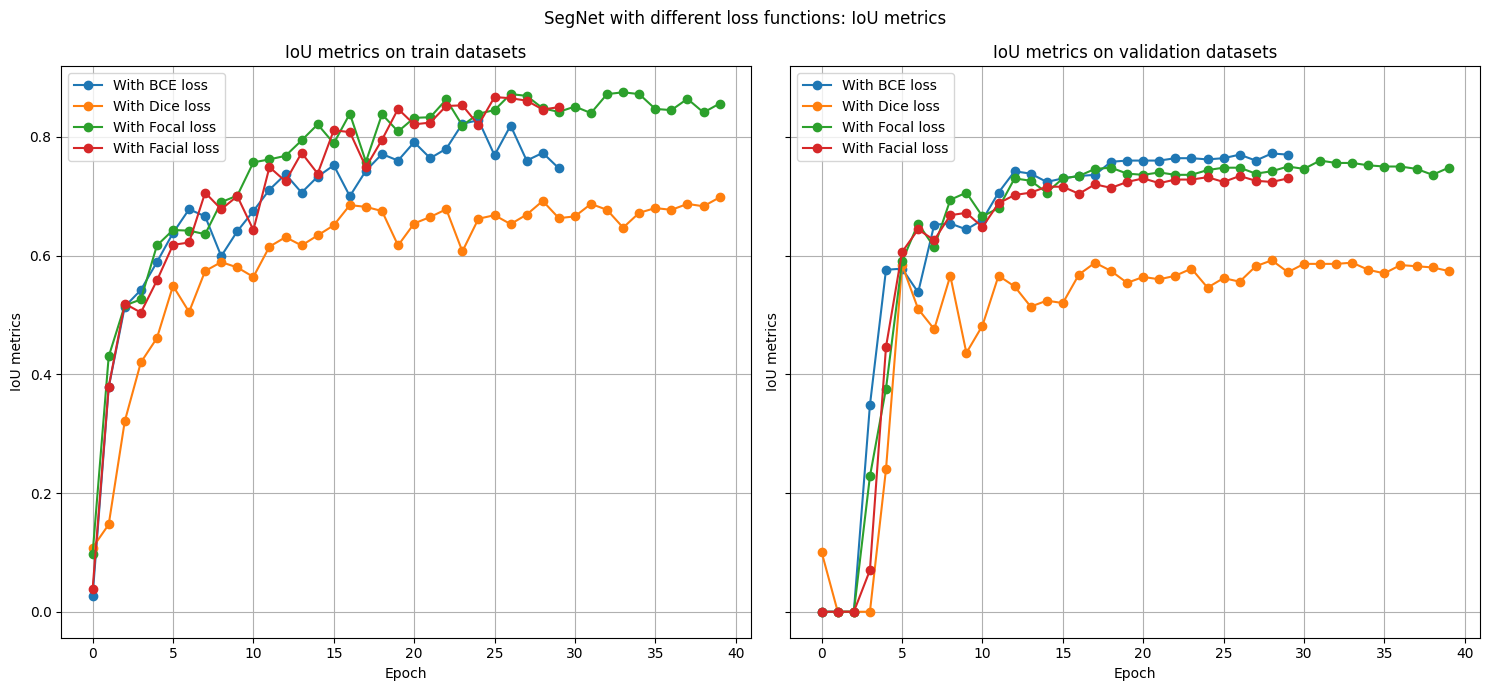

In [4]:
while True:
    fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
    ax[0].plot(SegNet_bce['train_iou'][:], marker='o', label='With BCE loss')
    ax[0].plot(SegNet_dice['train_iou'][:], marker='o', label='With Dice loss')
    ax[0].plot(SegNet_focal['train_iou'][:], marker='o', label='With Focal loss')
    ax[0].plot(SegNet_facial['train_iou'][:], marker='o', label='With Facial loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('IoU metrics')
    ax[0].set_title('IoU metrics on train datasets')
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(SegNet_bce['val_iou'][:], marker='o', label='With BCE loss')
    ax[1].plot(SegNet_dice['val_iou'][:], marker='o', label='With Dice loss')
    ax[1].plot(SegNet_focal['val_iou'][:], marker='o', label='With Focal loss')
    ax[1].plot(SegNet_facial['val_iou'][:], marker='o', label='With Facial loss')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('IoU metrics')
    ax[1].set_title('IoU metrics on validation datasets')
    ax[1].grid(True)
    ax[1].legend()

    plt.suptitle('SegNet with different loss functions: IoU metrics')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

We can see although Focal and Facial losses show better results on training dataset, SegNet with BCE loss has higher generalization capability.

### UNet from the paper with mirror padding

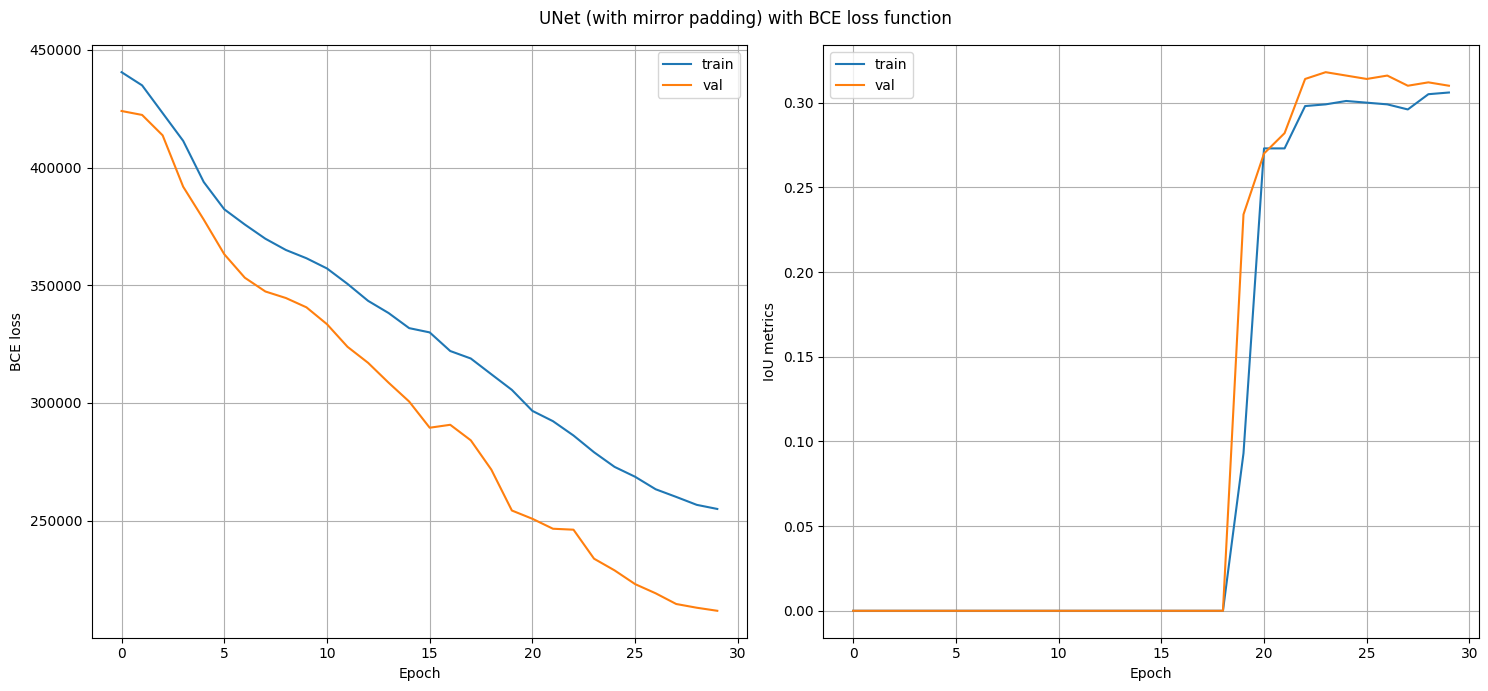

In [6]:
# import matplotlib.pyplot as plt

while True:
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].plot(UNet_bce['train_loss'][:], marker='', label='train')
    ax[0].plot(UNet_bce['val_loss'][:], marker='', label='val')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('BCE loss')
    # ax[0].set_title('BCE loss')
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(UNet_bce['train_iou'][:], marker='', label='train')
    ax[1].plot(UNet_bce['val_iou'][:], marker='', label='val')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('IoU metrics')
    # ax[0, 1].set_title('BCE loss')
    ax[1].grid(True)
    ax[1].legend()

    plt.suptitle('UNet (with mirror padding) with BCE loss function')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

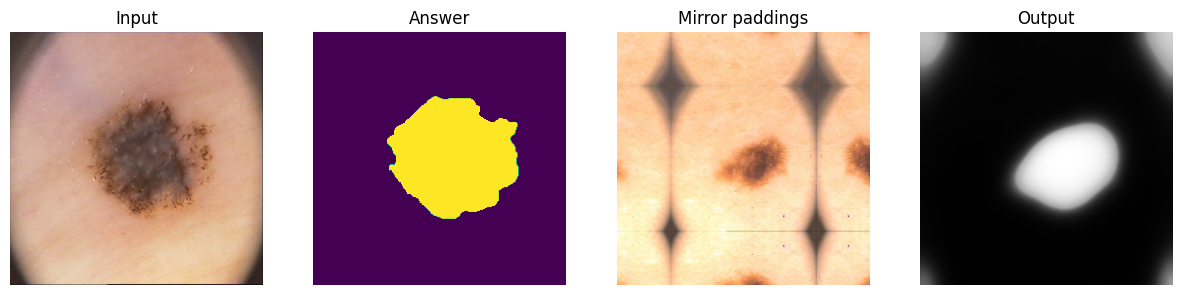

First I tried to implement the algorithm exactly like in the paper. I calculated how many pixels of mirror padding do I need to receive an image of the same size as the input in the end of the network. But this approach is not suitable for our problem.

On our pictures we highlight dark area with light surroundings. We can notice that in the corners there are also dark areas and as they don't havelighter surroundings they are not highlighted. But if we add wirror paddings we will get 4 more dark areas with light surroundings, which our model will highlight. This happens because in the paper authors dealt with repeating patterns but we don't have such.

To solve this problem I added simple padding for convolution layers, so that we take an image and give the answer of the same size without using mirror paddings.

### UNet with Upsampling

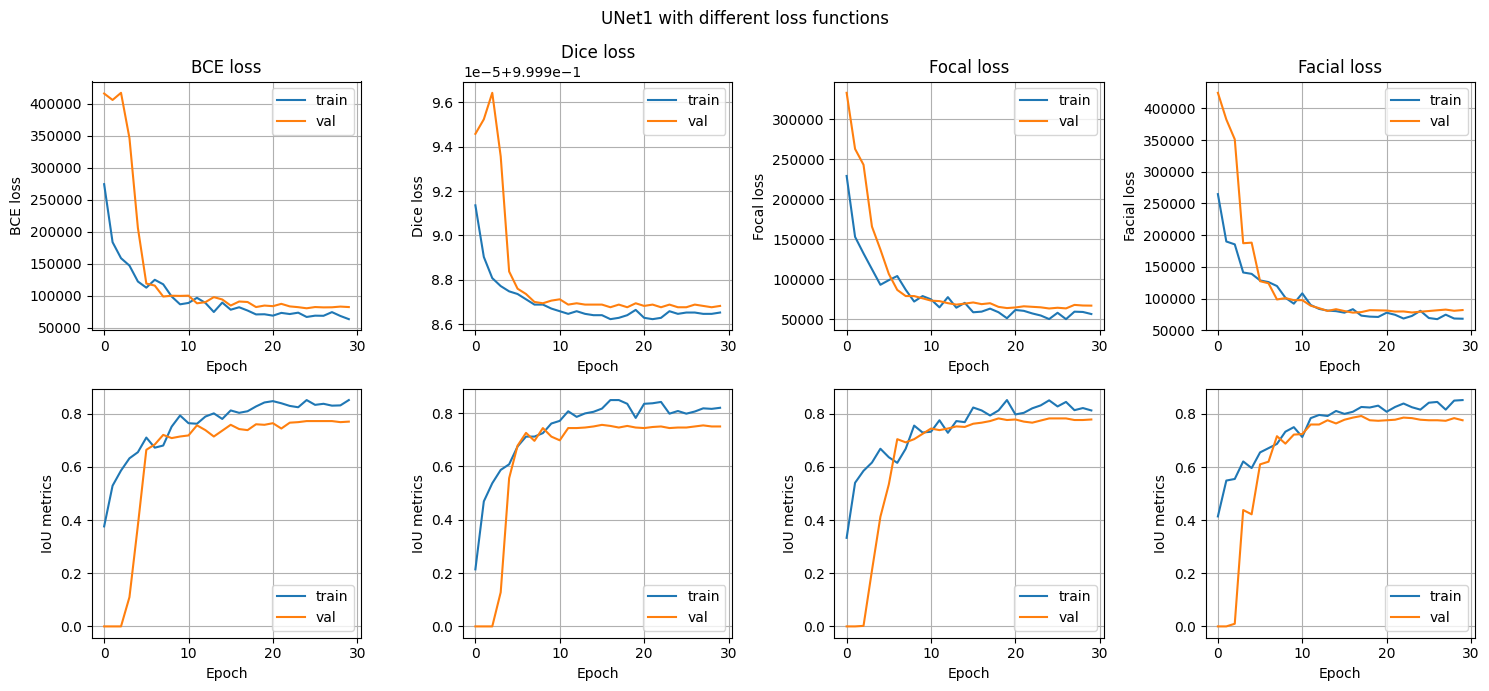

In [24]:
import matplotlib.pyplot as plt

while True:
    fig, ax = plt.subplots(2, 4, figsize=(15, 7))
    ax[0, 0].plot(UNet1_bce['train_loss'][:], marker='', label='train')
    ax[0, 0].plot(UNet1_bce['val_loss'][:], marker='', label='val')
    ax[0, 0].set_xlabel('Epoch')
    ax[0, 0].set_ylabel('BCE loss')
    ax[0, 0].set_title('BCE loss')
    ax[0, 0].grid(True)
    ax[0, 0].legend()

    ax[0, 1].plot(UNet1_dice['train_loss'][:], marker='', label='train')
    ax[0, 1].plot(UNet1_dice['val_loss'][:], marker='', label='val')
    ax[0, 1].set_xlabel('Epoch')
    ax[0, 1].set_ylabel('Dice loss')
    ax[0, 1].set_title('Dice loss')
    ax[0, 1].grid(True)
    ax[0, 1].legend()

    ax[0, 2].plot(UNet1_focal['train_loss'][:], marker='', label='train')
    ax[0, 2].plot(UNet1_focal['val_loss'][:], marker='', label='val')
    ax[0, 2].set_xlabel('Epoch')
    ax[0, 2].set_ylabel('Focal loss')
    ax[0, 2].set_title('Focal loss')
    ax[0, 2].grid(True)
    ax[0, 2].legend()

    ax[0, 3].plot(UNet1_facial['train_loss'][:], marker='', label='train')
    ax[0, 3].plot(UNet1_facial['val_loss'][:], marker='', label='val')
    ax[0, 3].set_xlabel('Epoch')
    ax[0, 3].set_ylabel('Facial loss')
    ax[0, 3].set_title('Facial loss')
    ax[0, 3].grid(True)
    ax[0, 3].legend()

    ax[1, 0].plot(UNet1_bce['train_iou'][:], marker='', label='train')
    ax[1, 0].plot(UNet1_bce['val_iou'][:], marker='', label='val')
    ax[1, 0].set_xlabel('Epoch')
    ax[1, 0].set_ylabel('IoU metrics')
    # ax[1, 0].set_title('BCE loss')
    ax[1, 0].grid(True)
    ax[1, 0].legend()

    ax[1, 1].plot(UNet1_dice['train_iou'][:], marker='', label='train')
    ax[1, 1].plot(UNet1_dice['val_iou'][:], marker='', label='val')
    ax[1, 1].set_xlabel('Epoch')
    ax[1, 1].set_ylabel('IoU metrics')
    # ax[1, 1].set_title('Dice loss')
    ax[1, 1].grid(True)
    ax[1, 1].legend()

    ax[1, 2].plot(UNet1_focal['train_iou'][:], marker='', label='train')
    ax[1, 2].plot(UNet1_focal['val_iou'][:], marker='', label='val')
    ax[1, 2].set_xlabel('Epoch')
    ax[1, 2].set_ylabel('IoU metrics')
    # ax[1, 2].set_title('Focal loss')
    ax[1, 2].grid(True)
    ax[1, 2].legend()

    ax[1, 3].plot(UNet1_facial['train_iou'][:], marker='', label='train')
    ax[1, 3].plot(UNet1_facial['val_iou'][:], marker='', label='val')
    ax[1, 3].set_xlabel('Epoch')
    ax[1, 3].set_ylabel('IoU metrics')
    # ax[1, 3].set_title('Facial loss')
    ax[1, 3].grid(True)
    ax[1, 3].legend()

    plt.suptitle('UNet1 with different loss functions')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

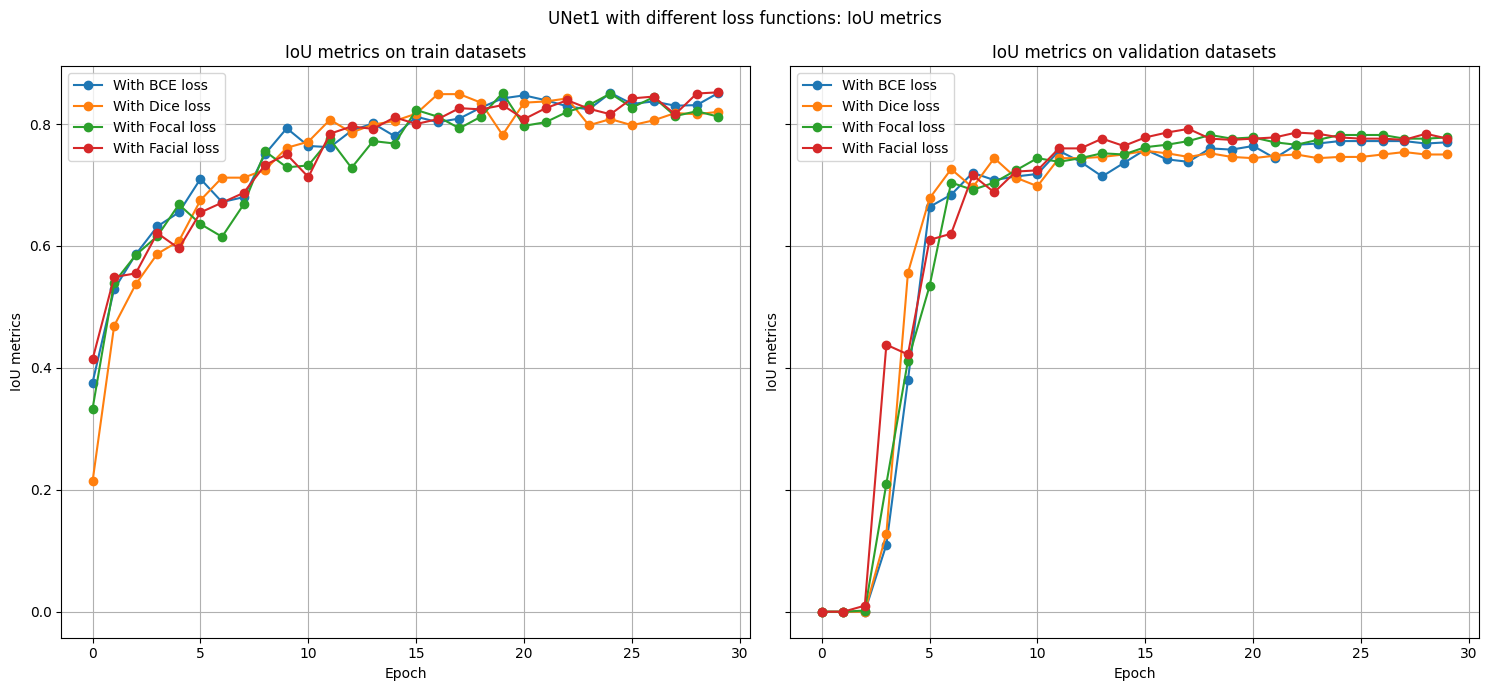

In [11]:
while True:
    fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
    ax[0].plot(UNet1_bce['train_iou'][:], marker='o', label='With BCE loss')
    ax[0].plot(UNet1_dice['train_iou'][:], marker='o', label='With Dice loss')
    ax[0].plot(UNet1_focal['train_iou'][:], marker='o', label='With Focal loss')
    ax[0].plot(UNet1_facial['train_iou'][:], marker='o', label='With Facial loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('IoU metrics')
    ax[0].set_title('IoU metrics on train datasets')
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(UNet1_bce['val_iou'][:], marker='o', label='With BCE loss')
    ax[1].plot(UNet1_dice['val_iou'][:], marker='o', label='With Dice loss')
    ax[1].plot(UNet1_focal['val_iou'][:], marker='o', label='With Focal loss')
    ax[1].plot(UNet1_facial['val_iou'][:], marker='o', label='With Facial loss')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('IoU metrics')
    ax[1].set_title('IoU metrics on validation datasets')
    ax[1].grid(True)
    ax[1].legend()

    plt.suptitle('UNet1 with different loss functions: IoU metrics')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

We can see UNet without mirror padding works well for our problem. All losses shows nearly same quality and marginal signs of overfitting. UNet looks more resilient for loss changes than SegNet.

### UNet with Transpose Convolution

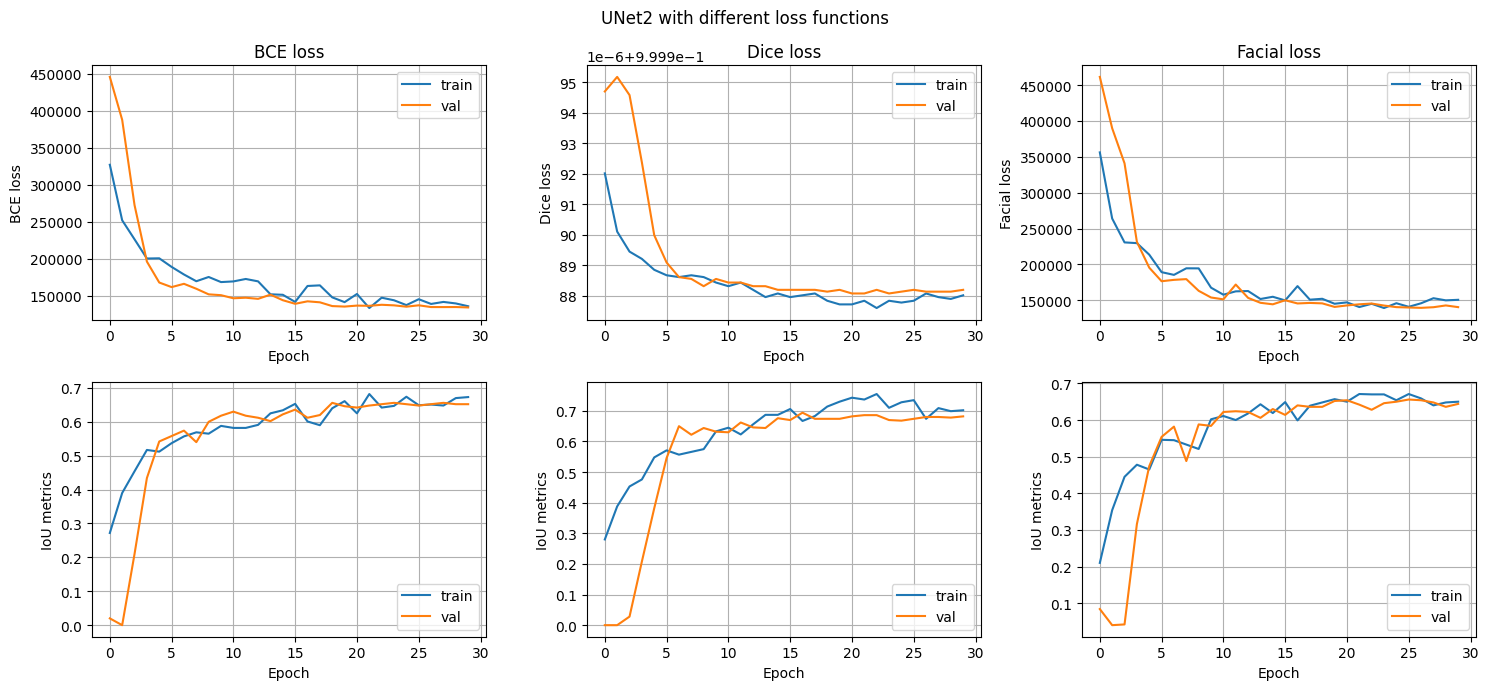

In [13]:
import matplotlib.pyplot as plt

while True:
    fig, ax = plt.subplots(2, 3, figsize=(15, 7))
    ax[0, 0].plot(UNet2_bce['train_loss'][:], marker='', label='train')
    ax[0, 0].plot(UNet2_bce['val_loss'][:], marker='', label='val')
    ax[0, 0].set_xlabel('Epoch')
    ax[0, 0].set_ylabel('BCE loss')
    ax[0, 0].set_title('BCE loss')
    ax[0, 0].grid(True)
    ax[0, 0].legend()

    ax[0, 1].plot(UNet2_dice['train_loss'][:], marker='', label='train')
    ax[0, 1].plot(UNet2_dice['val_loss'][:], marker='', label='val')
    ax[0, 1].set_xlabel('Epoch')
    ax[0, 1].set_ylabel('Dice loss')
    ax[0, 1].set_title('Dice loss')
    ax[0, 1].grid(True)
    ax[0, 1].legend()

    # ax[0, 2].plot(UNet2_focal['train_loss'][:], marker='', label='train')
    # ax[0, 2].plot(UNet2_focal['val_loss'][:], marker='', label='val')
    # ax[0, 2].set_xlabel('Epoch')
    # ax[0, 2].set_ylabel('Focal loss')
    # ax[0, 2].set_title('Focal loss')
    # ax[0, 2].grid(True)
    # ax[0, 2].legend()

    ax[0, 2].plot(UNet2_facial['train_loss'][:], marker='', label='train')
    ax[0, 2].plot(UNet2_facial['val_loss'][:], marker='', label='val')
    ax[0, 2].set_xlabel('Epoch')
    ax[0, 2].set_ylabel('Facial loss')
    ax[0, 2].set_title('Facial loss')
    ax[0, 2].grid(True)
    ax[0, 2].legend()

    ax[1, 0].plot(UNet2_bce['train_iou'][:], marker='', label='train')
    ax[1, 0].plot(UNet2_bce['val_iou'][:], marker='', label='val')
    ax[1, 0].set_xlabel('Epoch')
    ax[1, 0].set_ylabel('IoU metrics')
    # ax[1, 0].set_title('BCE loss')
    ax[1, 0].grid(True)
    ax[1, 0].legend()

    ax[1, 1].plot(UNet2_dice['train_iou'][:], marker='', label='train')
    ax[1, 1].plot(UNet2_dice['val_iou'][:], marker='', label='val')
    ax[1, 1].set_xlabel('Epoch')
    ax[1, 1].set_ylabel('IoU metrics')
    # ax[1, 1].set_title('Dice loss')
    ax[1, 1].grid(True)
    ax[1, 1].legend()

    # ax[1, 2].plot(UNet2_focal['train_iou'][:], marker='', label='train')
    # ax[1, 2].plot(UNet2_focal['val_iou'][:], marker='', label='val')
    # ax[1, 2].set_xlabel('Epoch')
    # ax[1, 2].set_ylabel('IoU metrics')
    # # ax[1, 2].set_title('Focal loss')
    # ax[1, 2].grid(True)
    # ax[1, 2].legend()

    ax[1, 2].plot(UNet2_facial['train_iou'][:], marker='', label='train')
    ax[1, 2].plot(UNet2_facial['val_iou'][:], marker='', label='val')
    ax[1, 2].set_xlabel('Epoch')
    ax[1, 2].set_ylabel('IoU metrics')
    # ax[1, 2].set_title('Facial loss')
    ax[1, 2].grid(True)
    ax[1, 2].legend()

    plt.suptitle('UNet2 with different loss functions')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

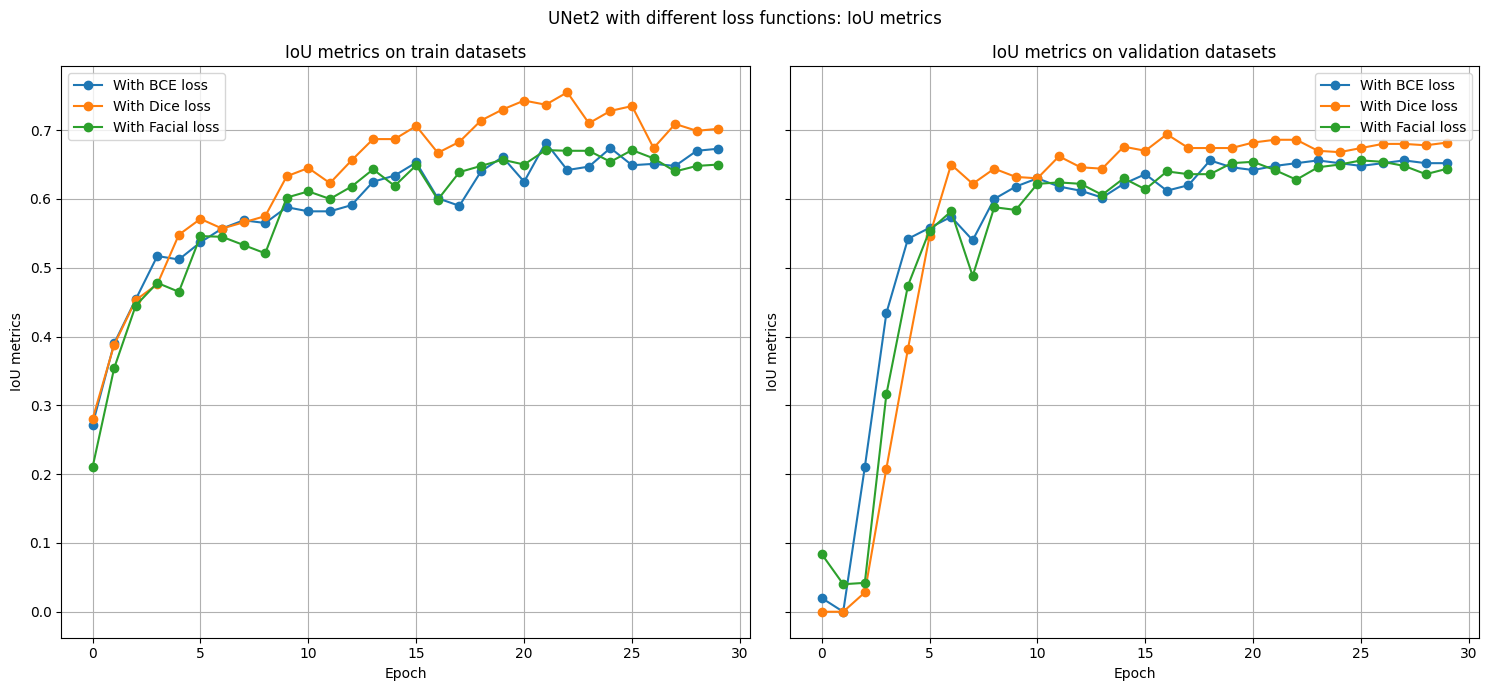

In [14]:
while True:
    fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
    ax[0].plot(UNet2_bce['train_iou'][:], marker='o', label='With BCE loss')
    ax[0].plot(UNet2_dice['train_iou'][:], marker='o', label='With Dice loss')
    # ax[0].plot(SegNet_focal['train_iou'][:], marker='o', label='With Focal loss')
    ax[0].plot(UNet2_facial['train_iou'][:], marker='o', label='With Facial loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('IoU metrics')
    ax[0].set_title('IoU metrics on train datasets')
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(UNet2_bce['val_iou'][:], marker='o', label='With BCE loss')
    ax[1].plot(UNet2_dice['val_iou'][:], marker='o', label='With Dice loss')
    # ax[1].plot(SegNet_focal['val_iou'][:], marker='o', label='With Focal loss')
    ax[1].plot(UNet2_facial['val_iou'][:], marker='o', label='With Facial loss')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('IoU metrics')
    ax[1].set_title('IoU metrics on validation datasets')
    ax[1].grid(True)
    ax[1].legend()

    plt.suptitle('UNet2 with different loss functions: IoU metrics')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

We can see that validation score is better with Dice loss but also this one shows more fluctuation during training. We don't see an evidently best loss function.

## Three algorithms, one loss

### BCE Loss

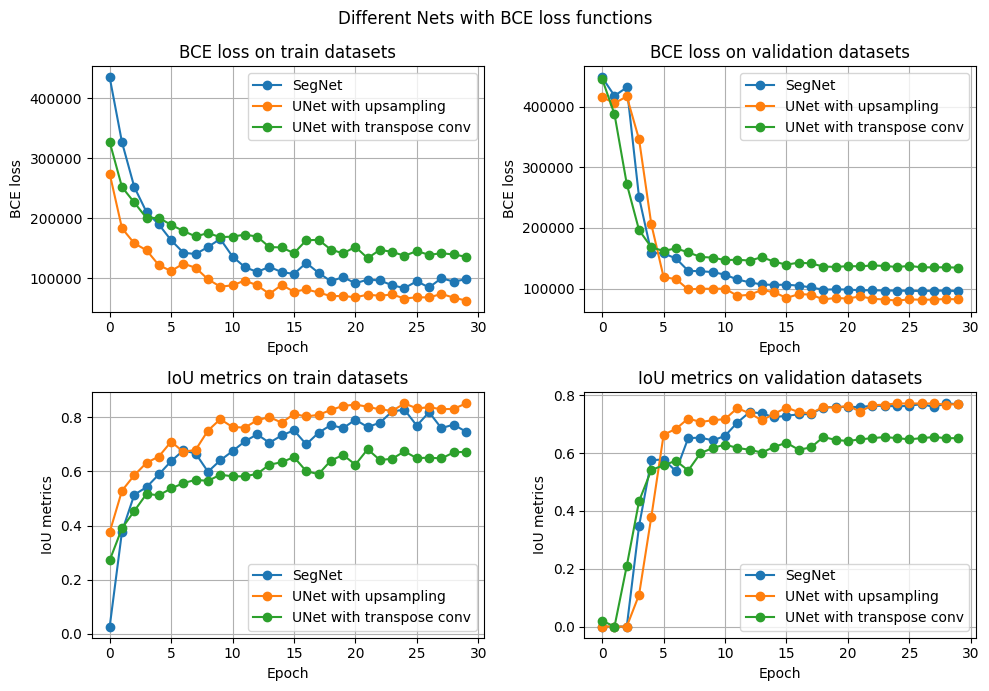

In [25]:
while True:
    fig, ax = plt.subplots(2, 2, figsize=(10, 7))
    ax[0,0].plot(SegNet_bce['train_loss'][:], marker='o', label='SegNet')
    ax[0,0].plot(UNet1_bce['train_loss'][:], marker='o', label='UNet with upsampling')
    ax[0,0].plot(UNet2_bce['train_loss'][:], marker='o', label='UNet with transpose conv')
    ax[0,0].set_xlabel('Epoch')
    ax[0,0].set_ylabel('BCE loss')
    ax[0,0].set_title('BCE loss on train datasets')
    ax[0,0].grid(True)
    ax[0,0].legend()

    ax[0,1].plot(SegNet_bce['val_loss'][:], marker='o', label='SegNet')
    ax[0,1].plot(UNet1_bce['val_loss'][:], marker='o', label='UNet with upsampling')
    ax[0,1].plot(UNet2_bce['val_loss'][:], marker='o', label='UNet with transpose conv')
    ax[0,1].set_xlabel('Epoch')
    ax[0,1].set_ylabel('BCE loss')
    ax[0,1].set_title('BCE loss on validation datasets')
    ax[0,1].grid(True)
    ax[0,1].legend()

    ax[1,0].plot(SegNet_bce['train_iou'][:], marker='o', label='SegNet')
    ax[1,0].plot(UNet1_bce['train_iou'][:], marker='o', label='UNet with upsampling')
    ax[1,0].plot(UNet2_bce['train_iou'][:], marker='o', label='UNet with transpose conv')
    ax[1,0].set_xlabel('Epoch')
    ax[1,0].set_ylabel('IoU metrics')
    ax[1,0].set_title('IoU metrics on train datasets')
    ax[1,0].grid(True)
    ax[1,0].legend()

    ax[1,1].plot(SegNet_bce['val_iou'][:], marker='o', label='SegNet')
    ax[1,1].plot(UNet1_bce['val_iou'][:], marker='o', label='UNet with upsampling')
    ax[1,1].plot(UNet2_bce['val_iou'][:], marker='o', label='UNet with transpose conv')
    ax[1,1].set_xlabel('Epoch')
    ax[1,1].set_ylabel('IoU metrics')
    ax[1,1].set_title('IoU metrics on validation datasets')
    ax[1,1].grid(True)
    ax[1,1].legend()

    plt.suptitle('Different Nets with BCE loss functions')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

### Dice Loss

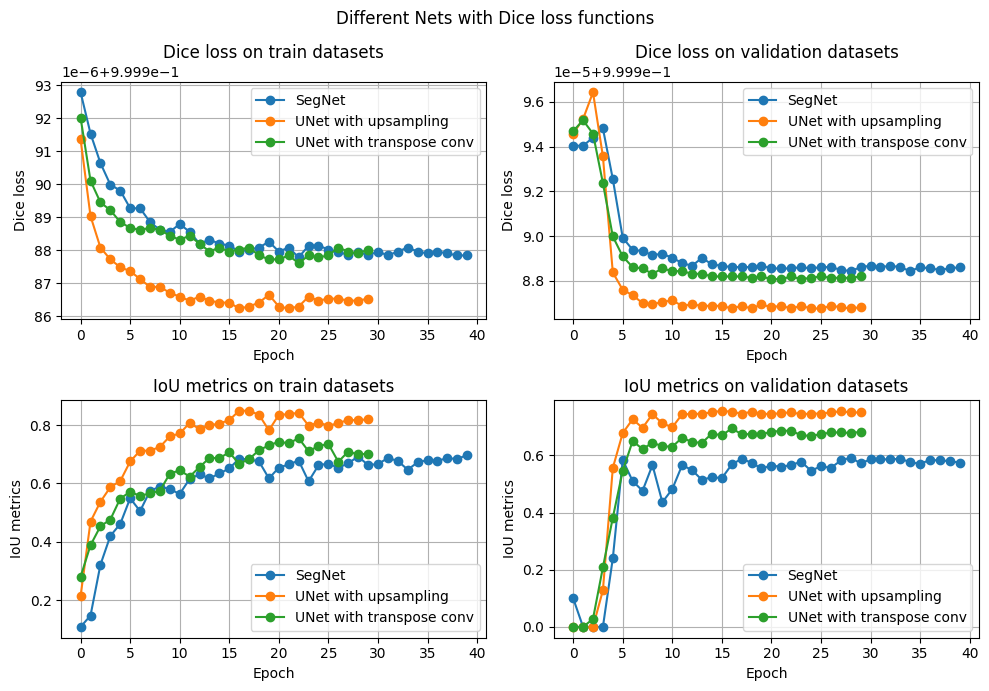

In [26]:
while True:
    fig, ax = plt.subplots(2, 2, figsize=(10, 7))
    ax[0,0].plot(SegNet_dice['train_loss'][:], marker='o', label='SegNet')
    ax[0,0].plot(UNet1_dice['train_loss'][:], marker='o', label='UNet with upsampling')
    ax[0,0].plot(UNet2_dice['train_loss'][:], marker='o', label='UNet with transpose conv')
    ax[0,0].set_xlabel('Epoch')
    ax[0,0].set_ylabel('Dice loss')
    ax[0,0].set_title('Dice loss on train datasets')
    ax[0,0].grid(True)
    ax[0,0].legend()

    ax[0,1].plot(SegNet_dice['val_loss'][:], marker='o', label='SegNet')
    ax[0,1].plot(UNet1_dice['val_loss'][:], marker='o', label='UNet with upsampling')
    ax[0,1].plot(UNet2_dice['val_loss'][:], marker='o', label='UNet with transpose conv')
    ax[0,1].set_xlabel('Epoch')
    ax[0,1].set_ylabel('Dice loss')
    ax[0,1].set_title('Dice loss on validation datasets')
    ax[0,1].grid(True)
    ax[0,1].legend()

    ax[1,0].plot(SegNet_dice['train_iou'][:], marker='o', label='SegNet')
    ax[1,0].plot(UNet1_dice['train_iou'][:], marker='o', label='UNet with upsampling')
    ax[1,0].plot(UNet2_dice['train_iou'][:], marker='o', label='UNet with transpose conv')
    ax[1,0].set_xlabel('Epoch')
    ax[1,0].set_ylabel('IoU metrics')
    ax[1,0].set_title('IoU metrics on train datasets')
    ax[1,0].grid(True)
    ax[1,0].legend()

    ax[1,1].plot(SegNet_dice['val_iou'][:], marker='o', label='SegNet')
    ax[1,1].plot(UNet1_dice['val_iou'][:], marker='o', label='UNet with upsampling')
    ax[1,1].plot(UNet2_dice['val_iou'][:], marker='o', label='UNet with transpose conv')
    ax[1,1].set_xlabel('Epoch')
    ax[1,1].set_ylabel('IoU metrics')
    ax[1,1].set_title('IoU metrics on validation datasets')
    ax[1,1].grid(True)
    ax[1,1].legend()

    plt.suptitle('Different Nets with Dice loss functions')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

### Focal Loss

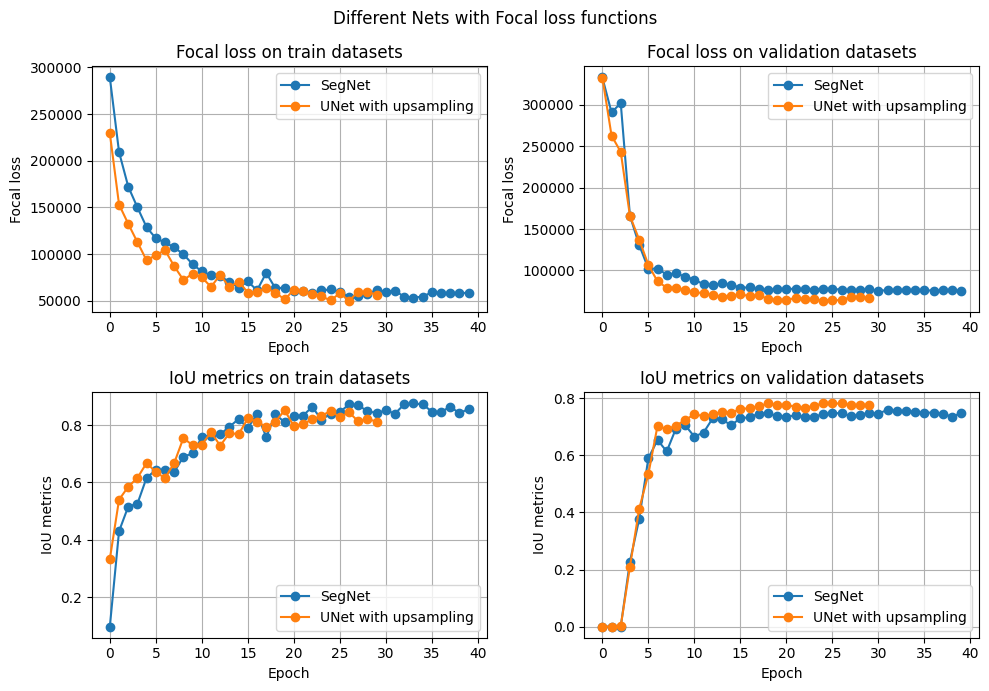

In [27]:
while True:
    fig, ax = plt.subplots(2, 2, figsize=(10, 7))
    ax[0,0].plot(SegNet_focal['train_loss'][:], marker='o', label='SegNet')
    ax[0,0].plot(UNet1_focal['train_loss'][:], marker='o', label='UNet with upsampling')
    # ax[0,0].plot(UNet2_focal['train_loss'][:], marker='o', label='UNet with transpose conv')
    ax[0,0].set_xlabel('Epoch')
    ax[0,0].set_ylabel('Focal loss')
    ax[0,0].set_title('Focal loss on train datasets')
    ax[0,0].grid(True)
    ax[0,0].legend()

    ax[0,1].plot(SegNet_focal['val_loss'][:], marker='o', label='SegNet')
    ax[0,1].plot(UNet1_focal['val_loss'][:], marker='o', label='UNet with upsampling')
    # ax[0,1].plot(UNet2_focal['val_loss'][:], marker='o', label='UNet with transpose conv')
    ax[0,1].set_xlabel('Epoch')
    ax[0,1].set_ylabel('Focal loss')
    ax[0,1].set_title('Focal loss on validation datasets')
    ax[0,1].grid(True)
    ax[0,1].legend()

    ax[1,0].plot(SegNet_focal['train_iou'][:], marker='o', label='SegNet')
    ax[1,0].plot(UNet1_focal['train_iou'][:], marker='o', label='UNet with upsampling')
    # ax[1,0].plot(UNet2_focal['train_iou'][:], marker='o', label='UNet with transpose conv')
    ax[1,0].set_xlabel('Epoch')
    ax[1,0].set_ylabel('IoU metrics')
    ax[1,0].set_title('IoU metrics on train datasets')
    ax[1,0].grid(True)
    ax[1,0].legend()

    ax[1,1].plot(SegNet_focal['val_iou'][:], marker='o', label='SegNet')
    ax[1,1].plot(UNet1_focal['val_iou'][:], marker='o', label='UNet with upsampling')
    # ax[1,1].plot(unet2_focal['val_iou'][:], marker='o', label='UNet with transpose conv')
    ax[1,1].set_xlabel('Epoch')
    ax[1,1].set_ylabel('IoU metrics')
    ax[1,1].set_title('IoU metrics on validation datasets')
    ax[1,1].grid(True)
    ax[1,1].legend()

    plt.suptitle('Different Nets with Focal loss functions')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

### Facial Loss

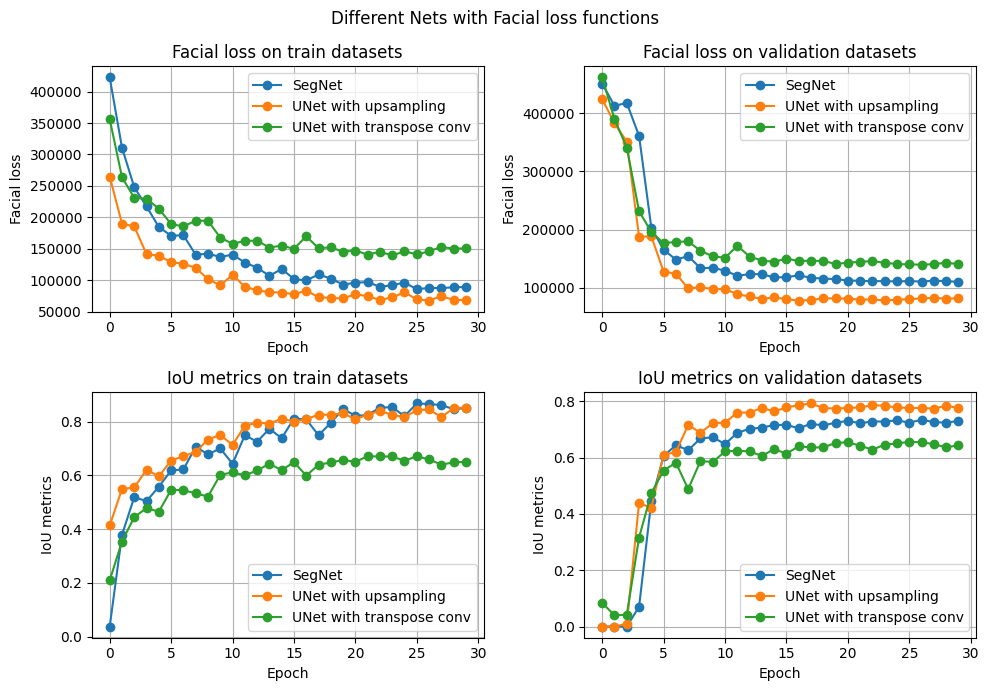

In [28]:
while True:
    fig, ax = plt.subplots(2, 2, figsize=(10, 7))
    ax[0,0].plot(SegNet_facial['train_loss'][:], marker='o', label='SegNet')
    ax[0,0].plot(UNet1_facial['train_loss'][:], marker='o', label='UNet with upsampling')
    ax[0,0].plot(UNet2_facial['train_loss'][:], marker='o', label='UNet with transpose conv')
    ax[0,0].set_xlabel('Epoch')
    ax[0,0].set_ylabel('Facial loss')
    ax[0,0].set_title('Facial loss on train datasets')
    ax[0,0].grid(True)
    ax[0,0].legend()

    ax[0,1].plot(SegNet_facial['val_loss'][:], marker='o', label='SegNet')
    ax[0,1].plot(UNet1_facial['val_loss'][:], marker='o', label='UNet with upsampling')
    ax[0,1].plot(UNet2_facial['val_loss'][:], marker='o', label='UNet with transpose conv')
    ax[0,1].set_xlabel('Epoch')
    ax[0,1].set_ylabel('Facial loss')
    ax[0,1].set_title('Facial loss on validation datasets')
    ax[0,1].grid(True)
    ax[0,1].legend()

    ax[1,0].plot(SegNet_facial['train_iou'][:], marker='o', label='SegNet')
    ax[1,0].plot(UNet1_facial['train_iou'][:], marker='o', label='UNet with upsampling')
    ax[1,0].plot(UNet2_facial['train_iou'][:], marker='o', label='UNet with transpose conv')
    ax[1,0].set_xlabel('Epoch')
    ax[1,0].set_ylabel('IoU metrics')
    ax[1,0].set_title('IoU metrics on train datasets')
    ax[1,0].grid(True)
    ax[1,0].legend()

    ax[1,1].plot(SegNet_facial['val_iou'][:], marker='o', label='SegNet')
    ax[1,1].plot(UNet1_facial['val_iou'][:], marker='o', label='UNet with upsampling')
    ax[1,1].plot(UNet2_facial['val_iou'][:], marker='o', label='UNet with transpose conv')
    ax[1,1].set_xlabel('Epoch')
    ax[1,1].set_ylabel('IoU metrics')
    ax[1,1].set_title('IoU metrics on validation datasets')
    ax[1,1].grid(True)
    ax[1,1].legend()

    plt.suptitle('Different Nets with Facial loss functions')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

Comparing models we can see that UNet with transpose convolution works worse that one with unpooling. Unpooling layers save more information to transfer it further than transpose convolution layers.

### Best losses, all models

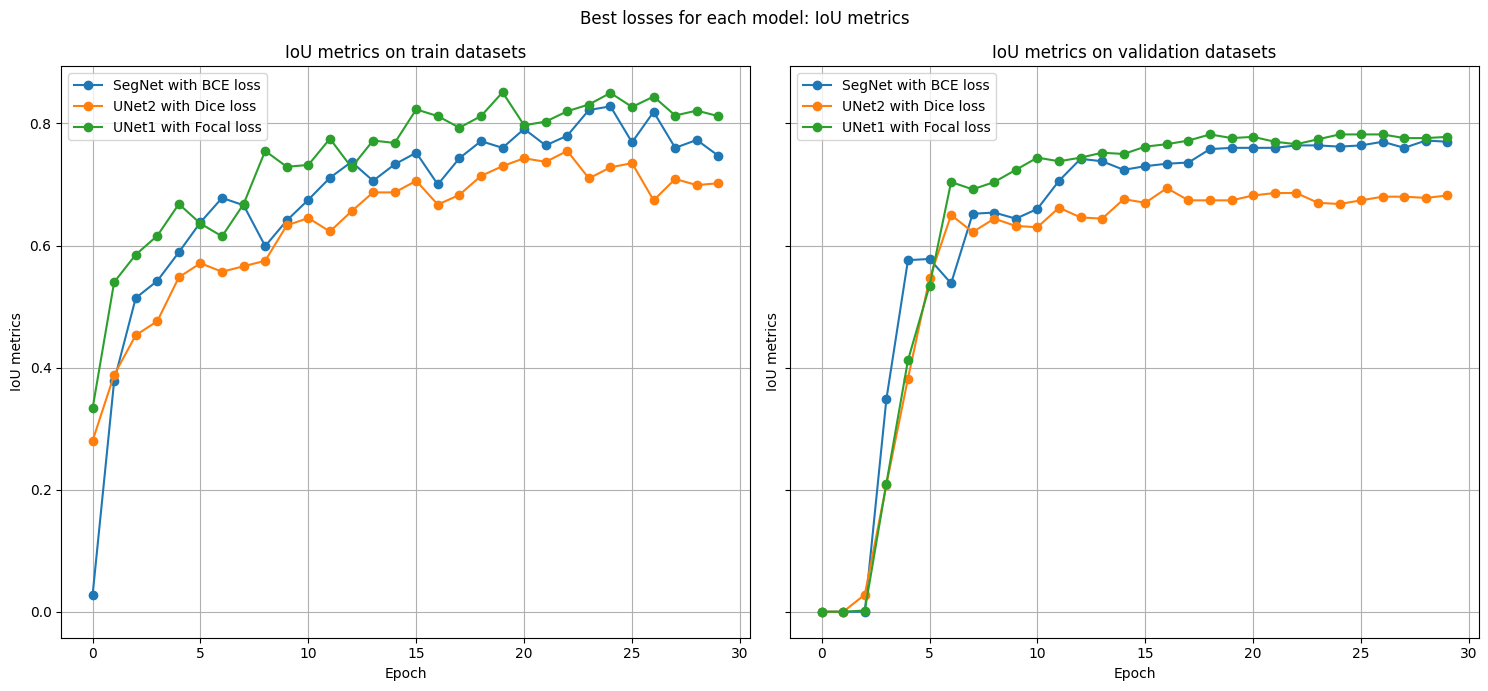

In [23]:
while True:
    fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
    ax[0].plot(SegNet_bce['train_iou'][:], marker='o', label='SegNet with BCE loss')
    ax[0].plot(UNet2_dice['train_iou'][:], marker='o', label='UNet2 with Dice loss')
    ax[0].plot(UNet1_focal['train_iou'][:], marker='o', label='UNet1 with Focal loss')
    # ax[0].plot(SegNet_facial['train_iou'][:], marker='o', label='With Facial loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('IoU metrics')
    ax[0].set_title('IoU metrics on train datasets')
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(SegNet_bce['val_iou'][:], marker='o', label='SegNet with BCE loss')
    ax[1].plot(UNet2_dice['val_iou'][:], marker='o', label='UNet2 with Dice loss')
    ax[1].plot(UNet1_focal['val_iou'][:], marker='o', label='UNet1 with Focal loss')
    # ax[1].plot(SegNet_facial['val_iou'][:], marker='o', label='With Facial loss')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('IoU metrics')
    ax[1].set_title('IoU metrics on validation datasets')
    ax[1].grid(True)
    ax[1].legend()

    plt.suptitle('Best losses for each model: IoU metrics')
    # Adjust layout to prevent overlap and make the first subplot taller
    plt.tight_layout()#rect=[0, 0, 1, 0.95])  # Adjust the rect parameter to modify subplot heights
    plt.show()
    break

We can see that UNet with upsampling and SegNet show close results. Although final validation score is higher with UNet1, SegNet has less signs of overfitting. So, choice should be done carefully and consider the specific of the problem. For instance, you may want to train your model faster and have less number of parameters. In this case SegNet is better (for our problem).



Model  -  Time to train 1 epoch  -  Number of parameters

SegNet -  4.42696c  -  29 443 585

UNet1  -  8.12006c  -  31 045 569

UNet2  -  8.88809c  -  46 715 649




